# OpenAI Strategic Finance — Compute, Product, and GTM Allocation

> **IMPORTANT — Read this first.** This analysis is based on **external research using public data only**, current as of **April 25, 2026**. No internal OpenAI data was used. All segment-level numbers are *modeled*, *back-solved*, or *calibrated* to public anchors. **Conclusions may be wrong**, especially where the notebook substitutes assumption for measurement (cost-to-serve, churn, CAC, elasticities). See **§13** for a map of which sections would change with internal data.

**Author posture:** Senior Staff DS, Strategic Finance.
**Question:** Where should OpenAI allocate the *next* dollar of compute, product, and GTM investment?
**Inputs:** Public anchors and modeled segment splits (see disclaimer above).
**Companion narrative:** [`deep-research-report.md`](deep-research-report.md).

## 0. TLDR

**Executive answer:** allocate the next scarce dollar to usage that is both sticky and metered: core API production traffic, Enterprise seats with credit pools, Business seats that expand into advanced credits, and Codex or agentic workloads sold on usage-aligned pricing. Consumer Plus remains strategically important, but free-tier expansion and flat-priced Pro-heavy usage should be compute-guarded.

| Key finding | Actionable insight for executives |
|---|---|
| Enterprise and API are the highest-quality growth engines | Bias 75% of incremental inference capacity toward metered enterprise/API traffic and 25% toward consumer paid reliability and conversion |
| Codex and agentic workflows deserve more capacity and GTM support | Scale them with metered or hybrid pricing, not blanket entitlement |
| Routing and pricing discipline are the fastest margin levers | Prioritize mini-model routing, Batch/Flex adoption, credit UX, workload observability, and cost-aware defaults |
| Consumer is valuable but economically uneven | Keep Plus strong, but move the heaviest Pro and premium advanced-tool usage toward thresholds, credits, and overages |
| Base-case economics can improve materially | The model reaches $35.2B ARR, $17.8B contribution, and 50% contribution margin if enterprise/API mix rises and monetization improves |

**Immediate leadership moves:** approve the compute allocation rule, simplify enterprise credit packaging, run Pro overage experiments, shift GTM toward partner-led deployment and post-sales expansion, and build a product-line P&L with per-feature serving cost and cohort LTV/CAC.

This notebook operationalizes the report. Every modeled number is either (a) anchored to a public fact, (b) derived from anchored facts via formulas in this notebook, or (c) synthesized and explicitly calibrated to a report endpoint. The final cell runs a **tie-out audit** against the report's modeled tables.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from dataclasses import dataclass, field
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

import plotly.graph_objects as go
import plotly.express as px
from plotly.io import renderers

from scipy import stats
from scipy.optimize import brentq

from IPython.display import display, Markdown

In [2]:
# Plot styling — finance-meeting standard, PDF-friendly
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
})

PALETTE = {
    'green':   '#10a37f',  # OpenAI green
    'ink':     '#202123',  # near-black
    'slate':   '#6e6e80',  # secondary text
    'cloud':   '#f7f7f8',  # background
    'red':     '#d64545',
    'amber':   '#f5a524',
    'blue':    '#3b82f6',
    'purple':  '#8b5cf6',
}
SEQ = [PALETTE['green'], PALETTE['blue'], PALETTE['purple'], PALETTE['amber'], PALETTE['red'], PALETTE['slate'], PALETTE['ink'], '#0d8b6a']

def dollars(x, unit='B'):
    if abs(x) >= 1e9 and unit == 'B': return f"${x/1e9:,.1f}B"
    if abs(x) >= 1e6 and unit == 'M': return f"${x/1e6:,.1f}M"
    if abs(x) >= 1e3 and unit == 'K': return f"${x/1e3:,.0f}K"
    return f"${x:,.0f}"

def pct(x, dp=0):
    return f"{x*100:.{dp}f}%"

In [3]:
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
RNG = np.random.default_rng(RANDOM_SEED)

## 1. Public anchors

Everything below ties back to a public source cited in `deep-research-report.md`.

- **Run-rate ARR ≈ $25B** (end-Feb 2026, line 5)
- **900M weekly active users**, **50M consumer subscribers**, **9M paying business users**, **>40% enterprise revenue share**, **15B API tokens/min**, **ads pilot >$100M ARR** (line 5)
- **Prices:** Go $8, Plus $20, Pro $100/$200, Business $25/$20; **API**: GPT-5.4 mini $0.75/$4.50, GPT-5.5 $5/$30, realtime audio $32/$64; **Batch 50% off**, Flex lower-priority (line 7)
- **Enterprise usage signals:** 7M workplace seats, 9× ENT seat YoY, 19× Custom GPTs/Projects, 320× reasoning-token consumption, 9k orgs >10B tokens, ~200 orgs >1T tokens (line 41)
- **Compute history:** 2023 $2B/0.2GW → 2024 $6B/0.6GW → 2025 $20B+/1.9GW. Implied $/GW ≈ $10B (line 62)
- **Ads pilot:** >$100M ARR, 600+ advertisers, 85% eligible, <20% shown daily (line 84)

In [4]:
ANCHORS = dict(
    arr_total=25.0e9,
    wau=900e6,
    consumer_subs=50e6,
    biz_users=9e6,
    enterprise_revenue_share=0.40,
    api_tokens_per_min=15e9,
    ads_arr_pilot=100e6,
    ent_seats=7e6,
    ent_seat_yoy=9.0,
    custom_gpt_yoy=19.0,
    reasoning_tokens_yoy=320.0,
    orgs_above_10B_tokens=9_000,
    orgs_above_1T_tokens=200,
    prices=dict(
        go=8, plus=20, pro_low=100, pro_high=200,
        biz_monthly=25, biz_annual=20,
    ),
    api_prices=dict(  # $ per 1M tokens
        gpt54_mini_in=0.75, gpt54_mini_out=4.50,
        gpt55_in=5.00,      gpt55_out=30.00,
        realtime_in=32.0,   realtime_out=64.0,
        web_search_per_1k=10.0,
    ),
    batch_discount=0.50,
    compute_history=[
        dict(year=2023, arr=2.0e9, gw=0.2),
        dict(year=2024, arr=6.0e9, gw=0.6),
        dict(year=2025, arr=20.0e9, gw=1.9),
    ],
)

# Tie-out tracker (populated through the notebook, printed in the final audit cell)
TIE_OUT = []
def record_tie(metric, report_val, nb_val, tol_pct=None, tol_pp=None, fmt='num'):
    TIE_OUT.append(dict(metric=metric, report=report_val, notebook=nb_val,
                        tol_pct=tol_pct, tol_pp=tol_pp, fmt=fmt))

In [5]:
# Compute history → $/GW historical anchor
ch = pd.DataFrame.from_records(ANCHORS['compute_history'])
ch['arr_per_gw_B'] = ch['arr'] / ch['gw'] / 1e9
ch_2025_arr_per_gw = ch.iloc[-1]['arr_per_gw_B']
print(ch.to_string(index=False))
print(f"\n2025 implied $/GW: ${ch_2025_arr_per_gw:.1f}B  (report line 62 says ≈ $10B)")
assert 8.5 <= ch_2025_arr_per_gw <= 11.5, f"$/GW {ch_2025_arr_per_gw:.1f} outside ±15% of $10B"
record_tie("Historical $/GW (2025)", 10.0, ch_2025_arr_per_gw, tol_pct=15)

 year          arr  gw  arr_per_gw_B
 2023 2.000000e+09 0.2     10.000000
 2024 6.000000e+09 0.6     10.000000
 2025 2.000000e+10 1.9     10.526316

2025 implied $/GW: $10.5B  (report line 62 says ≈ $10B)


**Comment**
- **Learnings:** 2025 ARR per GW is about $10.5B, close to the $10B public anchor.
- **Methodology:** Convert the compute history table into ARR/GW and assert it stays within the tolerance band.
- **Assumptions:** ARR and GW anchors are comparable across years and the 2025 figure is representative.


## 2. Decision: where the next compute dollar should go

**Headline:** 75% of incremental compute toward metered enterprise/API; 25% toward consumer paid (lines 13–17).

Specifically: **45% Core API text/mini · 30% metered Codex/agent · 15% Business + paid consumer · ≤10% free expansion.**

Rationale: durable economics live where usage is *both sticky and metered* (line 9). Free-tier and Pro flat-bundle inflate compute draw without proportional monetization.

In [6]:
incremental_alloc = pd.DataFrame([
    dict(workload='Core API text/mini production',         pct=0.45, why='Highest $/compute, predictable, easy to route'),
    dict(workload='Metered Codex / agentic enterprise',     pct=0.30, why='Strong demand + WTP; meter to capture'),
    dict(workload='Business + high-conversion consumer paid', pct=0.15, why='Sticky seat motion → credit expansion'),
    dict(workload='Free-tier reliability + search',         pct=0.10, why='Strategic funnel; compute-guardrailed'),
])
assert abs(incremental_alloc['pct'].sum() - 1.0) < 1e-9
display(incremental_alloc.style.format({'pct': '{:.0%}'}).hide(axis='index'))

workload,pct,why
Core API text/mini production,45%,"Highest $/compute, predictable, easy to route"
Metered Codex / agentic enterprise,30%,Strong demand + WTP; meter to capture
Business + high-conversion consumer paid,15%,Sticky seat motion → credit expansion
Free-tier reliability + search,10%,Strategic funnel; compute-guardrailed


**Comment**
- **Learnings:** The recommended next-dollar compute split favors API mini/core and metered agentic workloads.
- **Methodology:** Allocate 100% of incremental capacity by workload and document the rationale for each bucket.
- **Assumptions:** Percentages are directional planning weights, not a hard capacity schedule.


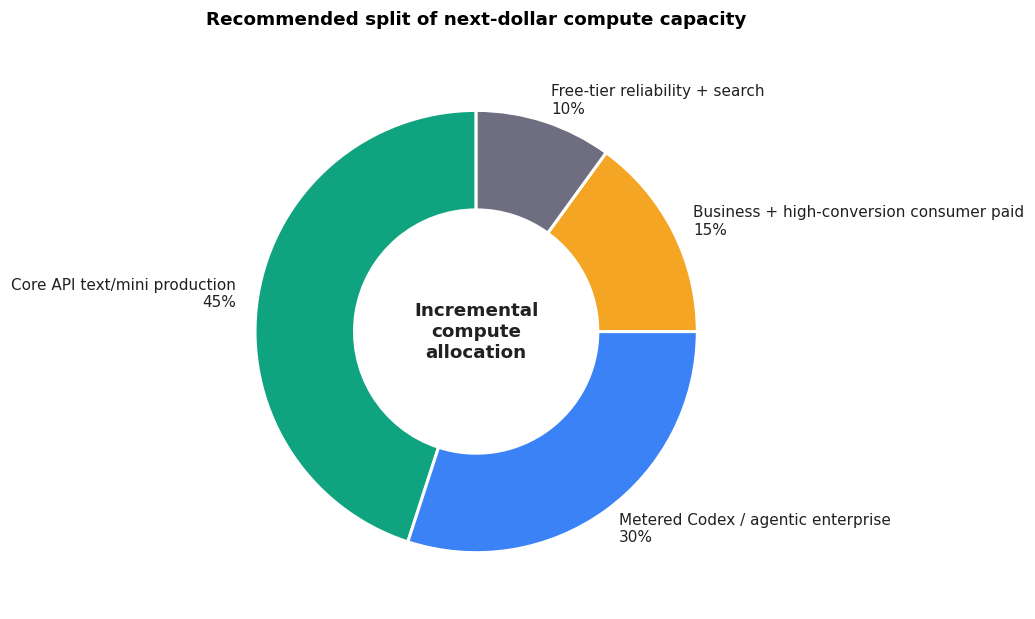

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sizes = incremental_alloc['pct'].values
labels = [f"{w}\n{p:.0%}" for w, p in zip(incremental_alloc['workload'], incremental_alloc['pct'])]
colors = [PALETTE['green'], PALETTE['blue'], PALETTE['amber'], PALETTE['slate']]
wedges, _ = ax.pie(sizes, labels=labels, colors=colors, startangle=90,
                   wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
                   textprops=dict(fontsize=10, color=PALETTE['ink']))
ax.text(0, 0, 'Incremental\ncompute\nallocation', ha='center', va='center',
        fontsize=12, fontweight='bold', color=PALETTE['ink'])
ax.set_title('Recommended split of next-dollar compute capacity', pad=20)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** The visual makes the 75% emphasis on API core plus metered Codex/agent workloads easy to see.
- **Methodology:** Render the allocation table as a donut chart with labels embedded in each segment.
- **Assumptions:** The prior allocation percentages are the decision basis for the chart.


## 3. Executive answer: which lines have the most durable economics?

"Durable economics" = high $/compute, recurring retention, expansion potential, pricing power, low spiky-usage sensitivity (line 9). Score each on 1–5, equal weights.

In [8]:
durable_axes = ['Compute ROI', 'Retention', 'Expansion', 'Pricing power', 'Abuse resistance']
durable_lines = [
    'API core text/mini',
    'Enterprise seats + credits',
    'Business seats',
    'Codex / agent (metered)',
    'Plus',
    'Pro (flat)',
    'Free + ads',
]
# Scores 1 (worst) – 5 (best). Calibrated qualitatively to the report.
durable_scores = np.array([
    [5, 5, 4, 5, 5],  # API core
    [5, 5, 5, 5, 5],  # Enterprise+credits
    [4, 4, 5, 4, 4],  # Business seats
    [4, 4, 5, 4, 3],  # Codex/agent metered
    [3, 4, 2, 3, 3],  # Plus
    [2, 3, 2, 2, 1],  # Pro flat
    [1, 2, 2, 1, 1],  # Free + ads
])
score_df = pd.DataFrame(durable_scores, index=durable_lines, columns=durable_axes)
score_df['Total'] = score_df.sum(axis=1)
score_df = score_df.sort_values('Total', ascending=False)
display(score_df.style.background_gradient(cmap='Greens', subset=durable_axes).format('{:d}'))

,Compute ROI,Retention,Expansion,Pricing power,Abuse resistance,Total
Enterprise seats + credits,5,5,5,5,5,25
API core text/mini,5,5,4,5,5,24
Business seats,4,4,5,4,4,21
Codex / agent (metered),4,4,5,4,3,20
Plus,3,4,2,3,3,15
Pro (flat),2,3,2,2,1,10
Free + ads,1,2,2,1,1,7


**Comment**
- **Learnings:** Enterprise seats plus credits and API core rank highest on durable economics.
- **Methodology:** Score each product line across compute ROI, retention, expansion, pricing power, and abuse resistance.
- **Assumptions:** The 1-5 scores are qualitative calibrations from the strategic-finance narrative.


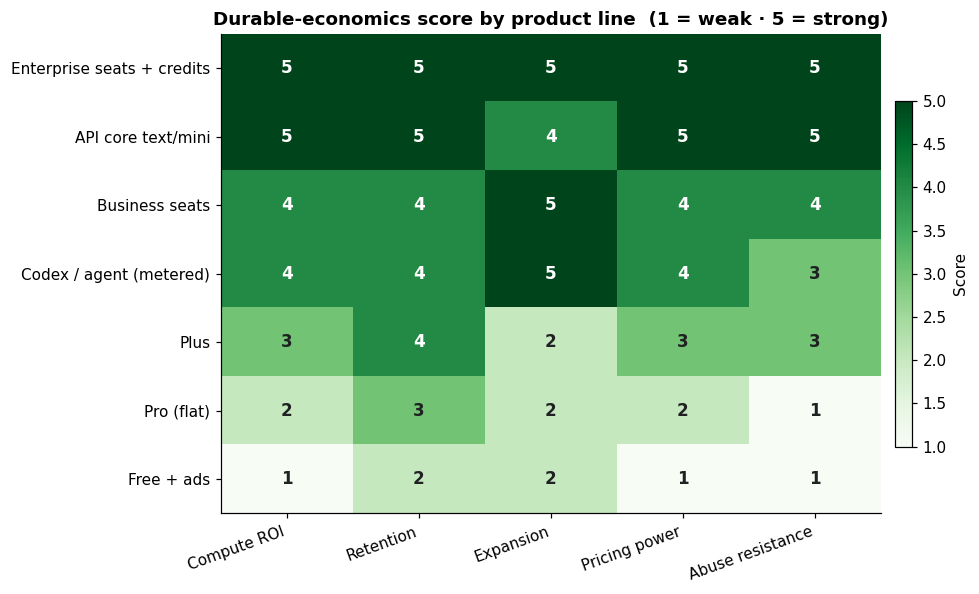

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
mat = score_df[durable_axes].values
im = ax.imshow(mat, cmap='Greens', vmin=1, vmax=5, aspect='auto')
ax.set_xticks(range(len(durable_axes)), durable_axes, rotation=20, ha='right')
ax.set_yticks(range(len(score_df)), score_df.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, mat[i, j], ha='center', va='center',
                color='white' if mat[i, j] >= 4 else PALETTE['ink'], fontsize=11, fontweight='bold')
ax.set_title('Durable-economics score by product line  (1 = weak · 5 = strong)')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Score')
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Durable-economics strength clusters in enterprise/API lines, while flat consumer/free lines lag.
- **Methodology:** Convert the score table into a heatmap to expose cross-axis strengths and weaknesses.
- **Assumptions:** Each axis has equal weight in the total durability view.


## 4. Unit economics: revenue, cost-to-serve, contribution margin

**This is the credibility section.** Approach:

| Bucket | Items |
|---|---|
| **ANCHORED (from report/public facts)** | Total ARR, API throughput, public prices |
| **MODELED** | Product-line ARR split, non-API token volume, workload mix |
| **CALIBRATED** | Effective per-token serving cost, support/infra allocation |
| **DERIVED** | Contribution, CM%, normalized segment mix |

Cost-to-serve is **not** a bottom-up margin proof because OpenAI's true serving cost by model/feature is not public. The notebook now reconciles the 15B API tokens/min anchor to annual API token volume, then back-solves effective serving cost per 1M tokens to the report's modeled cost endpoints. The tie-out audit checks consistency with the report model, not independent public-source truth.

In [10]:
# 4.1 Revenue by product line (anchored to report lines 24-34, normalized to ARR anchor)
revenue_by_line_raw = pd.DataFrame([
    dict(line='Free + ads',                arr_report=0.3e9, report_cost=0.9e9, report_cm=-2.00),
    dict(line='Go',                        arr_report=0.8e9, report_cost=0.5e9, report_cm=0.40),
    dict(line='Plus',                      arr_report=9.6e9, report_cost=4.3e9, report_cm=0.55),
    dict(line='Pro',                       arr_report=3.4e9, report_cost=2.9e9, report_cm=0.15),
    dict(line='Business seats',            arr_report=1.6e9, report_cost=0.6e9, report_cm=0.60),
    dict(line='Enterprise seats + credits', arr_report=2.0e9, report_cost=0.6e9, report_cm=0.68),
    dict(line='API core text/mini',        arr_report=4.7e9, report_cost=1.2e9, report_cm=0.75),
    dict(line='API frontier/Codex/realtime', arr_report=2.7e9, report_cost=1.4e9, report_cm=0.48),
])

ARR_SCALE = ANCHORS['arr_total'] / revenue_by_line_raw['arr_report'].sum()
revenue_by_line = revenue_by_line_raw.copy()
revenue_by_line['arr'] = revenue_by_line['arr_report'] * ARR_SCALE
revenue_by_line['arr_rounding_delta'] = revenue_by_line['arr'] - revenue_by_line['arr_report']

total_arr = revenue_by_line['arr'].sum()
print(f"Unscaled report table ARR: {dollars(revenue_by_line_raw['arr_report'].sum())}")
print(f"Normalization factor:       {ARR_SCALE:.6f}")
print(f"Total ARR:                  {dollars(total_arr)}  (anchor {dollars(ANCHORS['arr_total'])})")
assert abs(total_arr - ANCHORS['arr_total']) < 1, "ARR must equal public anchor after normalization"
record_tie("Total ARR ($B)", ANCHORS['arr_total']/1e9, total_arr/1e9, tol_pct=0.01)

Unscaled report table ARR: $25.1B
Normalization factor:       0.996016
Total ARR:                  $25.0B  (anchor $25.0B)


**Comment**
- **Learnings:** The product-line ARR table normalizes cleanly to the $25.0B anchor.
- **Methodology:** Scale the report-level ARR rows by one normalization factor and preserve the rounding delta.
- **Assumptions:** The source table mix is valid even after small proportional normalization.


In [11]:
# 4.2 Cost-to-serve from reconciled token volume + calibrated effective serving cost
# API tokens are anchored to the public 15B tokens/min signal. Non-API ChatGPT token
# volumes remain synthetic because no public per-tier token totals are disclosed.
API_ANNUAL_TOKENS_T = ANCHORS['api_tokens_per_min'] * 60 * 24 * 365 / 1e12
API_CORE_SHARE = 595 / (595 + 80)  # same modeled split as the original notebook
API_FRONTIER_SHARE = 1 - API_CORE_SHARE

COST_INPUTS = pd.DataFrame([
    # line, ann_tokens_T, mix_mini, mix_frontier, mix_realtime, active_users, infra_per_user, support_ratio, token_basis
    ['Free + ads',                 150,                                  0.90, 0.10, 0.00, 800e6,  0.30, 0.05, 'synthetic ChatGPT volume'],
    ['Go',                          80,                                  0.85, 0.15, 0.00,   8e6,  1.00, 0.05, 'synthetic ChatGPT volume'],
    ['Plus',                       750,                                  0.80, 0.20, 0.00,  40e6,  3.00, 0.02, 'synthetic ChatGPT volume'],
    ['Pro',                        240,                                  0.50, 0.50, 0.00,   2e6, 10.00, 0.02, 'synthetic ChatGPT volume'],
    ['Business seats',              60,                                  0.75, 0.20, 0.05,   6e6,  4.00, 0.10, 'synthetic workspace volume'],
    ['Enterprise seats + credits',  50,                                  0.65, 0.30, 0.05,   1e6, 15.00, 0.10, 'synthetic workspace volume'],
    ['API core text/mini',         API_ANNUAL_TOKENS_T * API_CORE_SHARE, 0.95, 0.04, 0.01,   0  ,  0.00, 0.00, 'anchored API throughput'],
    ['API frontier/Codex/realtime', API_ANNUAL_TOKENS_T * API_FRONTIER_SHARE, 0.20, 0.60, 0.20, 0  ,  0.00, 0.00, 'anchored API throughput'],
], columns=['line', 'tokens_T', 'mix_mini', 'mix_frontier', 'mix_realtime',
            'active_users', 'infra_per_user', 'support_ratio', 'token_basis'])

# Public API prices are used as a relative price index only, not as OpenAI serving cost.
P = ANCHORS['api_prices']
def blend(in_, out_): return 0.5 * (in_ + out_)
list_price_per_M_mini      = blend(P['gpt54_mini_in'],  P['gpt54_mini_out'])
list_price_per_M_frontier  = blend(P['gpt55_in'],       P['gpt55_out'])
list_price_per_M_realtime  = blend(P['realtime_in'],    P['realtime_out'])

# Backward-compatible aliases for later exploratory cells that reference these names.
cost_per_M_mini = list_price_per_M_mini
cost_per_M_frontier = list_price_per_M_frontier
cost_per_M_realtime = list_price_per_M_realtime

COST_INPUTS = COST_INPUTS.merge(revenue_by_line[['line', 'arr', 'report_cost']], on='line')
COST_INPUTS['tok_M'] = COST_INPUTS['tokens_T'] * 1e6
COST_INPUTS['infra'] = COST_INPUTS['active_users'] * COST_INPUTS['infra_per_user']
COST_INPUTS['support'] = COST_INPUTS['arr'] * COST_INPUTS['support_ratio']
COST_INPUTS['inference_target'] = COST_INPUTS['report_cost'] - COST_INPUTS['infra'] - COST_INPUTS['support']
assert (COST_INPUTS['inference_target'] > 0).all(), "Infra/support assumptions exceed report cost for at least one line"

COST_INPUTS['effective_cost_per_M'] = COST_INPUTS['inference_target'] / COST_INPUTS['tok_M']
COST_INPUTS['list_price_index_per_M'] = (
    COST_INPUTS['mix_mini'] * list_price_per_M_mini
    + COST_INPUTS['mix_frontier'] * list_price_per_M_frontier
    + COST_INPUTS['mix_realtime'] * list_price_per_M_realtime
)
COST_INPUTS['effective_cost_vs_public_price_index'] = COST_INPUTS['effective_cost_per_M'] / COST_INPUTS['list_price_index_per_M']
COST_INPUTS['inference'] = COST_INPUTS['inference_target']
COST_INPUTS['cost_derived'] = COST_INPUTS['inference'] + COST_INPUTS['infra'] + COST_INPUTS['support']

api_modeled_tokens_T = COST_INPUTS.loc[COST_INPUTS['token_basis'].eq('anchored API throughput'), 'tokens_T'].sum()
print(f"API throughput anchor: {ANCHORS['api_tokens_per_min']/1e9:.1f}B tokens/min = {API_ANNUAL_TOKENS_T:,.0f}T tokens/year")
print(f"Modeled API tokens:    {api_modeled_tokens_T:,.0f}T tokens/year")
assert abs(api_modeled_tokens_T - API_ANNUAL_TOKENS_T) / API_ANNUAL_TOKENS_T < 1e-12
record_tie("API annual tokens from throughput (T)", API_ANNUAL_TOKENS_T, api_modeled_tokens_T, tol_pct=0.01)

cmp = COST_INPUTS[['line', 'tokens_T', 'effective_cost_per_M', 'cost_derived']].merge(
    revenue_by_line[['line', 'report_cost']], on='line')
cmp['delta_pct'] = (cmp['cost_derived'] - cmp['report_cost']) / cmp['report_cost']
cmp_disp = cmp.copy()
cmp_disp['tokens_T'] = cmp_disp['tokens_T'].apply(lambda x: f"{x:,.0f}T")
cmp_disp['effective_cost_per_M'] = cmp_disp['effective_cost_per_M'].apply(lambda x: f"${x:,.3f}")
cmp_disp['cost_derived'] = cmp_disp['cost_derived'].apply(dollars)
cmp_disp['report_cost']  = cmp_disp['report_cost'].apply(dollars)
cmp_disp['delta_pct']    = cmp_disp['delta_pct'].apply(lambda x: f"{x:+.1%}")
print("Cost-to-serve: calibrated model vs report endpoint")
print(cmp_disp.to_string(index=False))
assert np.allclose(cmp['cost_derived'], cmp['report_cost']), "Calibrated cost should equal report endpoint"

API throughput anchor: 15.0B tokens/min = 7,884T tokens/year
Modeled API tokens:    7,884T tokens/year
Cost-to-serve: calibrated model vs report endpoint
                       line tokens_T effective_cost_per_M cost_derived  report_cost delta_pct
                 Free + ads     150T               $4.300 $900,000,000 $900,000,000     +0.0%
                         Go      80T               $5.652 $500,000,000 $500,000,000     +0.0%
                       Plus     750T               $5.318        $4.3B        $4.3B     +0.0%
                        Pro     240T              $11.718        $2.9B        $2.9B     +0.0%
             Business seats      60T               $6.944 $600,000,000 $600,000,000     +0.0%
 Enterprise seats + credits      50T               $7.716 $600,000,000 $600,000,000     +0.0%
         API core text/mini   6,950T               $0.173        $1.2B        $1.2B     +0.0%
API frontier/Codex/realtime     934T               $1.498        $1.4B        $1.4B     +0.0%


**Comment**
- **Learnings:** Calibrated cost-to-serve matches every report endpoint while preserving the API token throughput anchor.
- **Methodology:** Combine modeled token volume, mix, infra, and support inputs, then calibrate to report costs.
- **Assumptions:** Non-API ChatGPT token volumes are synthetic because public per-tier usage is not disclosed.


In [12]:
# 4.3 Build unit_econ_df with calibrated cost
unit_econ = revenue_by_line[['line', 'arr']].merge(
    COST_INPUTS[['line', 'cost_derived']], on='line')
unit_econ.columns = ['line', 'arr', 'cost']
unit_econ['contribution'] = unit_econ['arr'] - unit_econ['cost']
unit_econ['cm_pct'] = unit_econ['contribution'] / unit_econ['arr']

total_cost = unit_econ['cost'].sum()
total_contrib = unit_econ['contribution'].sum()
total_cm = total_contrib / unit_econ['arr'].sum()
print(f"Total cost (calibrated): {dollars(total_cost)}  (report ~$12.4B)")
print(f"Total contribution:      {dollars(total_contrib)}")
print(f"Total CM%:               {pct(total_cm, 1)}  (report ~50%)")
assert abs(total_cm - 0.50) < 0.04, f"Total CM% {total_cm:.1%} >4pp off 50%"
record_tie("Total cost-to-serve ($B)", 12.4, total_cost/1e9, tol_pct=1)
record_tie("Total CM (%)", 50.0, total_cm*100, tol_pp=4)

display(unit_econ.style.format({
    'arr': lambda x: dollars(x),
    'cost': lambda x: dollars(x),
    'contribution': lambda x: dollars(x),
    'cm_pct': '{:.0%}',
}).background_gradient(subset=['cm_pct'], cmap='RdYlGn', vmin=-2, vmax=0.8))

Total cost (calibrated): $12.4B  (report ~$12.4B)
Total contribution:      $12.6B
Total CM%:               50.4%  (report ~50%)


,line,arr,cost,contribution,cm_pct
0,Free + ads,"$298,804,781","$900,000,000","$-601,195,219",-201%
1,Go,"$796,812,749","$500,000,000","$296,812,749",37%
2,Plus,$9.6B,$4.3B,$5.3B,55%
3,Pro,$3.4B,$2.9B,"$486,454,183",14%
4,Business seats,$1.6B,"$600,000,000","$993,625,498",62%
5,Enterprise seats + credits,$2.0B,"$600,000,000",$1.4B,70%
6,API core text/mini,$4.7B,$1.2B,$3.5B,74%
7,API frontier/Codex/realtime,$2.7B,$1.4B,$1.3B,48%


**Comment**
- **Learnings:** Total contribution is about $12.6B and the blended contribution margin ties near 50%.
- **Methodology:** Merge normalized ARR with calibrated costs, compute contribution dollars and margin percent, then record tie-outs.
- **Assumptions:** Calibrated cost endpoints are appropriate for product-line margin analysis.


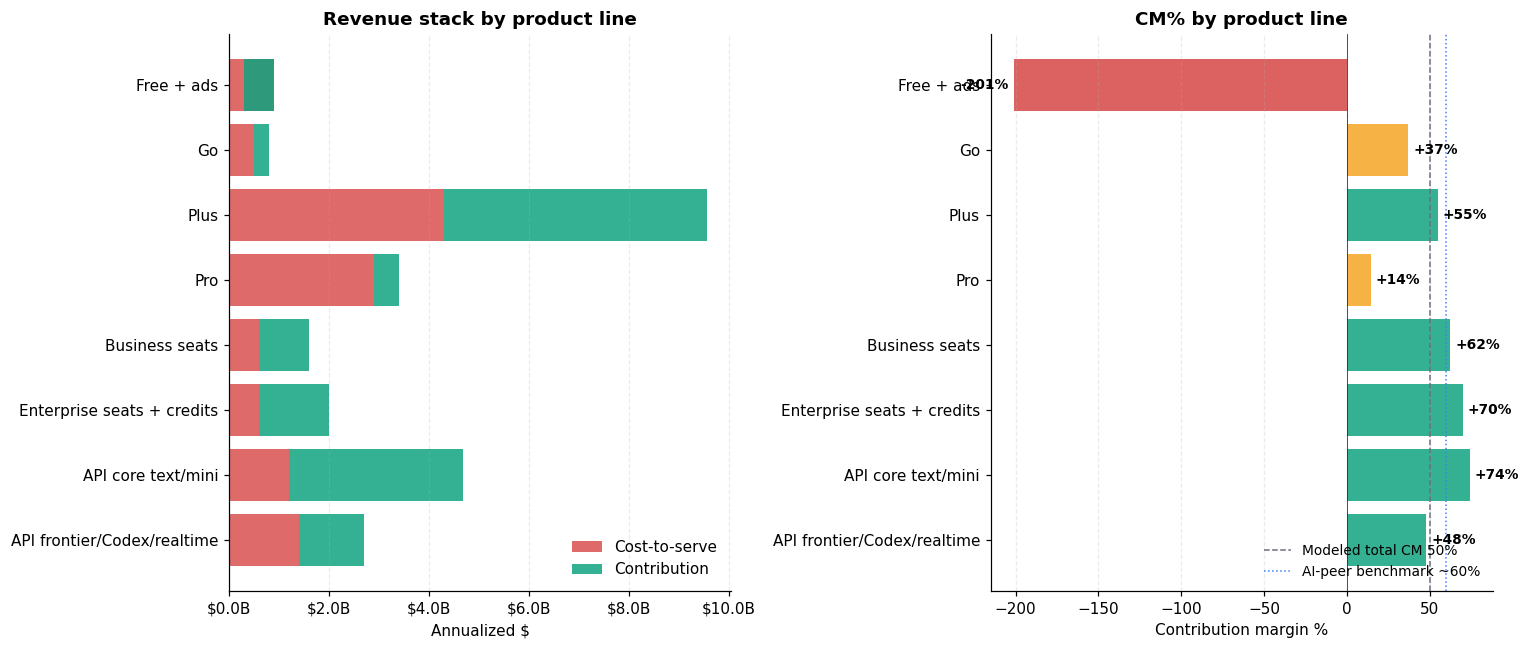

In [13]:
# 4.4 Charts: stacked bar + diverging CM%
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
y = np.arange(len(unit_econ))
ax.barh(y, unit_econ['cost']/1e9, color=PALETTE['red'], alpha=0.8, label='Cost-to-serve')
ax.barh(y, unit_econ['contribution']/1e9, left=unit_econ['cost']/1e9,
        color=PALETTE['green'], alpha=0.85, label='Contribution')
ax.set_yticks(y, unit_econ['line'])
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('Revenue stack by product line')
ax.set_xlabel('Annualized $')
ax.legend(loc='lower right', frameon=False)
ax.grid(axis='x', alpha=0.25)

ax = axes[1]
cm = unit_econ['cm_pct'].values
colors = [PALETTE['red'] if c < 0 else (PALETTE['amber'] if c < 0.45 else PALETTE['green']) for c in cm]
ax.barh(y, cm * 100, color=colors, alpha=0.85)
ax.axvline(0, color=PALETTE['ink'], lw=0.5)
ax.axvline(50, color=PALETTE['slate'], ls='--', lw=1, label='Modeled total CM 50%')
ax.axvline(60, color=PALETTE['blue'], ls=':', lw=1, label='AI-peer benchmark ~60%')
ax.set_yticks(y, unit_econ['line'])
ax.invert_yaxis()
ax.set_xlabel('Contribution margin %')
ax.set_title('CM% by product line')
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.grid(axis='x', alpha=0.25)
for yi, c in enumerate(cm):
    ax.text(c*100 + (3 if c >= 0 else -3), yi, f"{c:+.0%}",
            va='center', ha='left' if c >= 0 else 'right', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** API, enterprise, and business lines create the strongest margin pool; free and Pro are pressure points.
- **Methodology:** Plot cost and contribution as stacked revenue bars alongside product-line contribution margin.
- **Assumptions:** The modeled unit-economics table is the single source for the visualization.


## 5. LTV / CAC by cohort, with sensitivity

Six cohorts from the report (lines 47-55). Two LTV variants:
- **Report/simple tie-out:** `LTV = ARPU x gm / churn_monthly`; this is an undiscounted steady-state shorthand.
- **Decision view:** `LTV = sum_{t=0..60} ARPU x gm x (1-churn)^t / (1+r/12)^t`, r = 12%.

Charts and sensitivity use the 60-month DCF decision view. The simple view is retained only so the notebook can tie back to the report table.

In [14]:
COHORTS = pd.DataFrame([
    # name, arpu, gm, churn, cac, cohort_arr_M
    # NOTE on churn: these are *revenue* churn (back-solved from report LTVs), which is lower
    # than the monthly *user* churn used in §6 retention curves (e.g., Plus user churn ~8% but
    # revenue churn ~3.6% because Go->Plus conversions retain dollars in the cohort).
    dict(cohort='Consumer Go/Plus',         arpu=17,    gm=0.53, churn=0.036, cac=18,     arr=10.4e9 * ARR_SCALE),
    dict(cohort='Consumer Pro',             arpu=140,   gm=0.15, churn=0.046, cac=60,     arr=3.4e9 * ARR_SCALE),
    dict(cohort='Business self-serve seat', arpu=22,    gm=0.60, churn=0.015, cac=90,     arr=1.6e9 * ARR_SCALE),
    dict(cohort='Enterprise deployed seat', arpu=60,    gm=0.68, churn=0.006, cac=720,    arr=2.0e9 * ARR_SCALE),
    dict(cohort='API production account',   arpu=1500,  gm=0.75, churn=0.016, cac=7500,   arr=4.7e9 * ARR_SCALE),
    dict(cohort='Frontier/Codex large acct', arpu=20000, gm=0.48, churn=0.012, cac=150000, arr=2.7e9 * ARR_SCALE),
])

REPORT_TARGETS = pd.DataFrame([
    dict(cohort='Consumer Go/Plus',         ltv=253,    ltv_cac=14.0, payback=2.0),
    dict(cohort='Consumer Pro',             ltv=458,    ltv_cac=7.6,  payback=2.4),
    dict(cohort='Business self-serve seat', ltv=880,    ltv_cac=9.8,  payback=6.8),
    dict(cohort='Enterprise deployed seat', ltv=6800,   ltv_cac=9.4,  payback=17.6),
    dict(cohort='API production account',   ltv=70000,  ltv_cac=9.3,  payback=7.1),
    dict(cohort='Frontier/Codex large acct', ltv=800000, ltv_cac=5.3,  payback=15.6),
])

def ltv_simple(arpu, gm, churn):
    return arpu * gm / churn

def ltv_dcf(arpu, gm, churn, r=0.12, T=60):
    months = np.arange(T + 1)
    cf = arpu * gm * (1 - churn) ** months
    disc = (1 + r/12) ** months
    return (cf / disc).sum()

def payback_months(arpu, gm, cac):
    return cac / (arpu * gm)

ltv = COHORTS.copy()
ltv['ltv_simple'] = ltv.apply(lambda r: ltv_simple(r.arpu, r.gm, r.churn), axis=1)
ltv['ltv_dcf'] = ltv.apply(lambda r: ltv_dcf(r.arpu, r.gm, r.churn), axis=1)
ltv['payback'] = ltv.apply(lambda r: payback_months(r.arpu, r.gm, r.cac), axis=1)
ltv['ltv_cac_simple'] = ltv['ltv_simple'] / ltv['cac']
ltv['ltv_cac_dcf']    = ltv['ltv_dcf']    / ltv['cac']
ltv['decision_ltv'] = ltv['ltv_dcf']
ltv['decision_ltv_cac'] = ltv['ltv_cac_dcf']

cmp = ltv.merge(REPORT_TARGETS, on='cohort', suffixes=('_nb', '_rep'))
cmp_disp = cmp[['cohort', 'ltv_simple', 'ltv', 'ltv_cac_simple', 'ltv_cac', 'ltv_dcf', 'ltv_cac_dcf', 'payback_nb', 'payback_rep']].copy()
cmp_disp.columns = ['cohort', 'Simple LTV (NB)', 'Simple LTV (report)', 'Simple LTV/CAC (NB)', 'Simple LTV/CAC (R)', 'DCF LTV (decision)', 'DCF LTV/CAC', 'Payback (NB)', 'Payback (R)']
for col in ['Simple LTV (NB)', 'Simple LTV (report)', 'DCF LTV (decision)']:
    cmp_disp[col] = cmp_disp[col].apply(lambda x: f"${x:,.0f}")
for col in ['Simple LTV/CAC (NB)', 'Simple LTV/CAC (R)', 'DCF LTV/CAC']:
    cmp_disp[col] = cmp_disp[col].apply(lambda x: f"{x:.1f}x")
for col in ['Payback (NB)', 'Payback (R)']:
    cmp_disp[col] = cmp_disp[col].apply(lambda x: f"{x:.1f} mo")
display(cmp_disp.style.hide(axis='index'))

# Tie-out simple/undiscounted report shorthand only; DCF is the decision metric.
for _, r in cmp.iterrows():
    delta = (r.ltv_cac_simple - r.ltv_cac) / r.ltv_cac
    assert abs(delta) < 0.15, f"{r.cohort}: simple LTV/CAC off by {delta:.0%}"
    record_tie(f"Undiscounted LTV/CAC tie-out — {r.cohort}", r.ltv_cac, r.ltv_cac_simple, tol_pct=15, fmt='ratio')

cohort,Simple LTV (NB),Simple LTV (report),Simple LTV/CAC (NB),Simple LTV/CAC (R),DCF LTV (decision),DCF LTV/CAC,Payback (NB),Payback (R)
Consumer Go/Plus,$250,$253,13.9x,14.0x,$186,10.4x,2.0 mo,2.0 mo
Consumer Pro,$457,$458,7.6x,7.6x,$367,6.1x,2.9 mo,2.4 mo
Business self-serve seat,$880,$880,9.8x,9.8x,$418,4.6x,6.8 mo,6.8 mo
Enterprise deployed seat,"$6,800","$6,800",9.4x,9.4x,"$1,603",2.2x,17.6 mo,17.6 mo
API production account,"$70,312","$70,000",9.4x,9.3x,"$34,798",4.6x,6.7 mo,7.1 mo
Frontier/Codex large acct,"$800,000","$800,000",5.3x,5.3x,"$325,716",2.2x,15.6 mo,15.6 mo


**Comment**
- **Learnings:** DCF LTV/CAC remains attractive across cohorts, with Frontier/Codex and Pro more fragile than core API or enterprise.
- **Methodology:** Build cohort economics, compare simple report LTVs with 60-month DCF LTV, and calculate payback.
- **Assumptions:** Revenue churn differs from user churn because upgrades and expansion retain dollars inside cohorts.


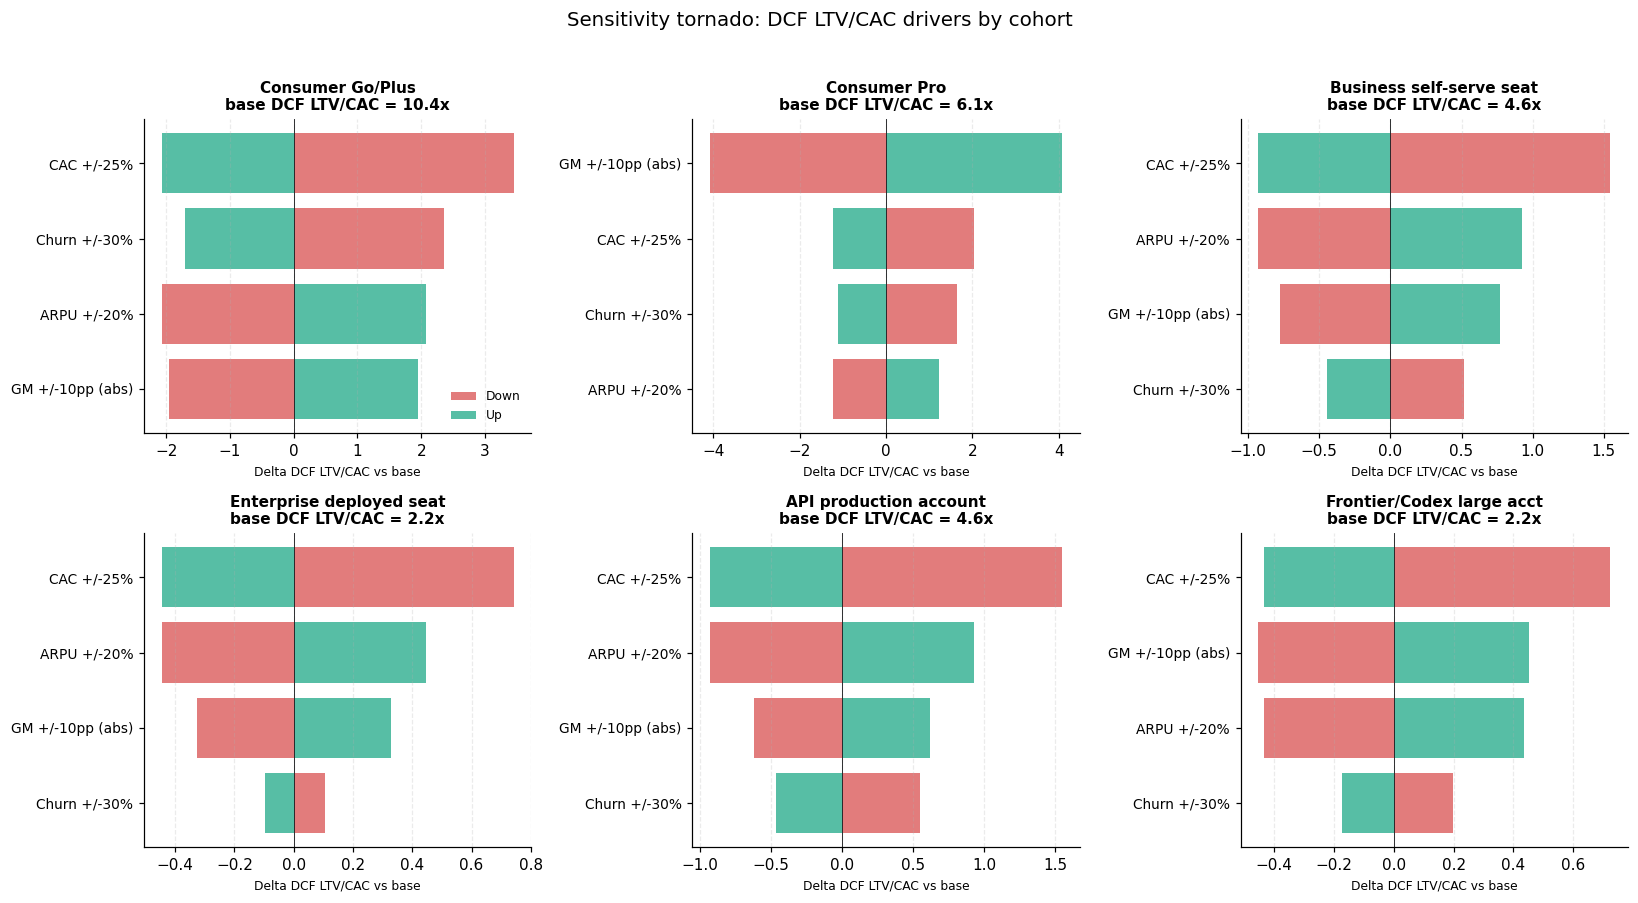

In [15]:
# 5.2 Tornado small multiples (one per cohort), using DCF LTV/CAC for decisioning
SWEEPS = [
    ('arpu',  0.20, 'ARPU +/-20%'),
    ('churn', 0.30, 'Churn +/-30%'),
    ('gm',    0.10, 'GM +/-10pp (abs)'),
    ('cac',   0.25, 'CAC +/-25%'),
]

def cohort_ltv_cac_dcf(row):
    return ltv_dcf(row.arpu, row.gm, row.churn) / row.cac

def tornado_for(row):
    base = cohort_ltv_cac_dcf(row)
    out = []
    for var, delta, label in SWEEPS:
        lo, hi = dict(row), dict(row)
        if var == 'gm':  # additive
            lo['gm'], hi['gm'] = max(0.01, row.gm - delta), min(0.99, row.gm + delta)
        else:
            lo[var], hi[var] = row[var] * (1 - delta), row[var] * (1 + delta)
        v_lo = ltv_dcf(lo['arpu'], lo['gm'], lo['churn']) / lo['cac']
        v_hi = ltv_dcf(hi['arpu'], hi['gm'], hi['churn']) / hi['cac']
        out.append((label, v_lo - base, v_hi - base))
    return base, out

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.flat, COHORTS.iterrows()):
    base, sweeps = tornado_for(row)
    sweeps = sorted(sweeps, key=lambda s: max(abs(s[1]), abs(s[2])), reverse=True)
    labels = [s[0] for s in sweeps]
    los    = [s[1] for s in sweeps]
    his    = [s[2] for s in sweeps]
    y = np.arange(len(labels))
    ax.barh(y, los, color=PALETTE['red'], alpha=0.7, label='Down')
    ax.barh(y, his, color=PALETTE['green'], alpha=0.7, label='Up')
    ax.set_yticks(y, labels, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color=PALETTE['ink'], lw=0.6)
    ax.set_title(f"{row.cohort}\nbase DCF LTV/CAC = {base:.1f}x", fontsize=10)
    ax.set_xlabel('Delta DCF LTV/CAC vs base', fontsize=8)
    ax.grid(axis='x', alpha=0.25)
axes.flat[0].legend(loc='lower right', frameon=False, fontsize=8)
plt.suptitle('Sensitivity tornado: DCF LTV/CAC drivers by cohort', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** LTV/CAC sensitivity is driven most by churn, ARPU, gross margin, and CAC depending on cohort shape.
- **Methodology:** Run one-way sweeps around each cohort and display the DCF LTV/CAC impact as tornado charts.
- **Assumptions:** Sweep ranges are local stress tests, not full probabilistic forecasts.


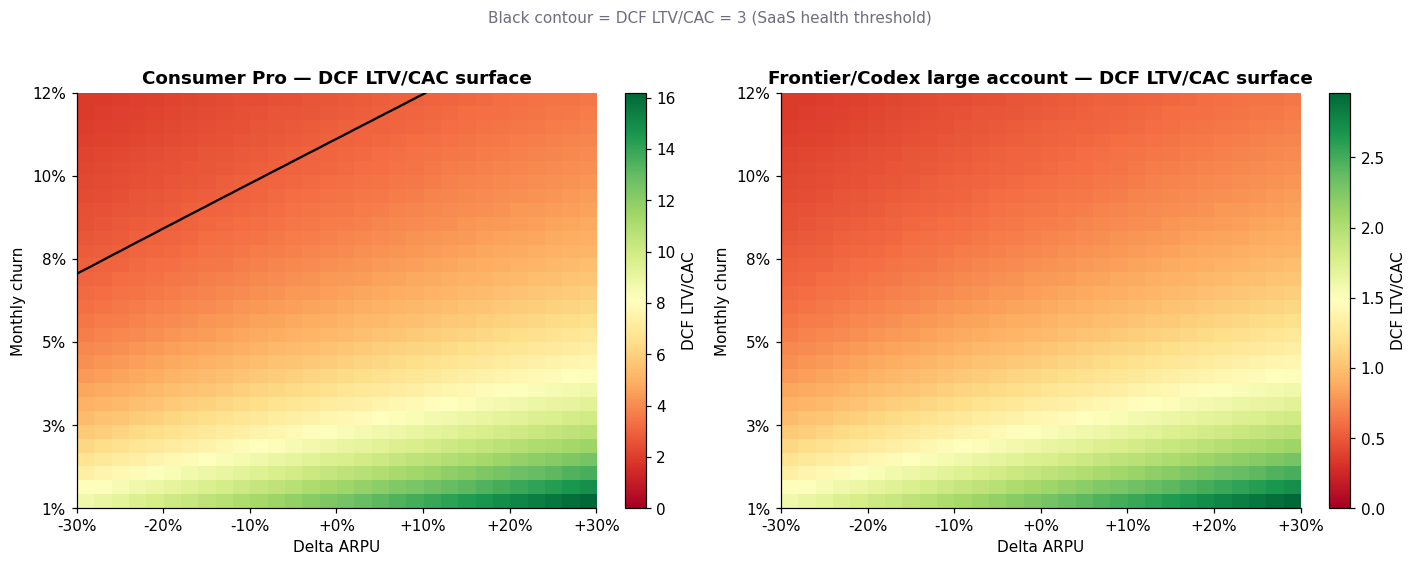

In [16]:
# 5.3 2D heatmap for the two fragile cohorts: Pro and Frontier/Codex, using DCF LTV/CAC
def heatmap_2d(ax, cohort_row, churn_grid, arpu_mult_grid, title):
    Z = np.zeros((len(churn_grid), len(arpu_mult_grid)))
    for i, c in enumerate(churn_grid):
        for j, m in enumerate(arpu_mult_grid):
            Z[i, j] = ltv_dcf(cohort_row.arpu * m, cohort_row.gm, c) / cohort_row.cac
    im = ax.imshow(Z, aspect='auto', origin='lower', cmap='RdYlGn',
                   extent=[arpu_mult_grid[0]-1, arpu_mult_grid[-1]-1,
                           churn_grid[0], churn_grid[-1]], vmin=0, vmax=Z.max())
    ax.contour(np.linspace(arpu_mult_grid[0]-1, arpu_mult_grid[-1]-1, len(arpu_mult_grid)),
               churn_grid, Z, levels=[3], colors='black', linewidths=1.5)
    ax.set_xlabel('Delta ARPU')
    ax.set_ylabel('Monthly churn')
    ax.set_xticks(np.linspace(-0.30, 0.30, 7))
    ax.set_xticklabels([f"{x:+.0%}" for x in np.linspace(-0.30, 0.30, 7)])
    ax.set_yticks(np.linspace(0.01, 0.12, 6))
    ax.set_yticklabels([f"{y:.0%}" for y in np.linspace(0.01, 0.12, 6)])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04, label='DCF LTV/CAC')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
churn_grid = np.linspace(0.01, 0.12, 30)
arpu_mult_grid = np.linspace(0.70, 1.30, 30)
heatmap_2d(axes[0], COHORTS.iloc[1], churn_grid, arpu_mult_grid, 'Consumer Pro — DCF LTV/CAC surface')
heatmap_2d(axes[1], COHORTS.iloc[5], churn_grid, arpu_mult_grid, 'Frontier/Codex large account — DCF LTV/CAC surface')
plt.suptitle('Black contour = DCF LTV/CAC = 3 (SaaS health threshold)', y=1.02, fontsize=10, color=PALETTE['slate'])
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Pro and Frontier/Codex economics need either ARPU upside or churn control to maintain strong LTV/CAC.
- **Methodology:** Evaluate DCF LTV/CAC over churn and ARPU grids and draw the 3x threshold contour.
- **Assumptions:** Gross margin and CAC stay fixed while ARPU and churn vary.


In [17]:
# 5.4 Plotly bubble — interactive #1; DCF is the decision LTV
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ltv['decision_ltv'], y=ltv['cac'],
    mode='markers+text',
    marker=dict(
        size=np.sqrt(ltv['arr']/1e9) * 18,
        color=ltv['payback'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(title='Payback<br>(months)'),
        line=dict(color='black', width=1),
        sizemode='diameter',
    ),
    text=ltv['cohort'],
    textposition='top center',
    hovertemplate=('<b>%{text}</b><br>'
                   'DCF LTV: $%{x:,.0f}<br>'
                   'CAC: $%{y:,.0f}<br>'
                   '<extra></extra>'),
))
fig.update_layout(
    title='DCF LTV vs CAC by cohort  (bubble size = ARR · color = payback)',
    xaxis=dict(type='log', title='60-month DCF LTV ($, log)'),
    yaxis=dict(type='log', title='CAC ($, log)'),
    width=900, height=550,
    template='plotly_white',
)
fig.show()

**Comment**
- **Learnings:** Cohorts with high CAC can still be attractive when DCF LTV and payback support the investment.
- **Methodology:** Plot DCF LTV against CAC on log axes, with bubble size tied to ARR and color tied to payback.
- **Assumptions:** ARR is a reasonable proxy for current cohort scale.


## 6. Cohort retention, expansion, margin, usage intensity

Public signals (lines 41 + 43): 9× ENT seat YoY · 8× weekly enterprise messages since Nov-2024 · 19× Custom GPTs/Projects · 320× reasoning-token consumption per org · 75% of workers report quality gain · 40–60min saved/active day · top decile uses 8× more credits.

Synthetic monthly cohort retention + NDR, calibrated so:
- **Plus** has ~8% monthly churn at month 12; **Enterprise** ~1%
- **Enterprise NDR @12mo lands inside 110–120% benchmark** (line 56)
- **Total Plus subs at month 12 ≈ 50M** (line 5)
- **Enterprise seats at month 24 ≈ 7M** (line 41)

In [18]:
# 6.1 Weibull retention curves: solve λ such that S(13)/S(12) = 1 - target_churn at t=12.
def solve_weibull(target_monthly_churn_at_12, k):
    # Find lambda so that S(13)/S(12) = 1 - c
    # S(t) = exp(-(t/λ)^k); S(13)/S(12) = exp(-((13/λ)^k - (12/λ)^k))
    target = -np.log(1 - target_monthly_churn_at_12)
    f = lambda lam: ((13/lam)**k - (12/lam)**k) - target
    return brentq(f, 1, 1e6)

retention_specs = [
    # cohort, target_monthly_churn, k_shape, expansion_per_month, monthly_inflow
    ('Plus',                    0.080, 1.05, 0.002,  5_000_000),
    ('Pro',                     0.060, 1.05, 0.000,    100_000),
    ('Business seat',           0.030, 1.00, 0.020,    200_000),
    ('Enterprise seat',         0.010, 0.85, 0.026,     50_000),
    ('API account',             0.020, 0.85, 0.030,        800),
    ('Frontier/Codex acct',     0.010, 0.85, 0.035,         30),
]

T_MAX = 24
months = np.arange(T_MAX + 1)
retention_curves = {}
weibull_params = {}
for cohort, churn, k, expansion, inflow in retention_specs:
    lam = solve_weibull(churn, k)
    weibull_params[cohort] = (lam, k, expansion, inflow)
    S = np.exp(-(months / lam) ** k)
    retention_curves[cohort] = S

ret_df = pd.DataFrame(retention_curves, index=months)
ret_df.index.name = 'month'
print("Retention at month 12:")
print(ret_df.iloc[12].apply(lambda x: f"{x:.1%}"))

Retention at month 12:
Plus                   38.6%
Pro                    49.4%
Business seat          69.4%
Enterprise seat        86.7%
API account            75.1%
Frontier/Codex acct    86.7%
Name: 12, dtype: object


**Comment**
- **Learnings:** Retention is materially stronger for enterprise and Frontier/Codex accounts than for consumer tiers.
- **Methodology:** Solve Weibull retention parameters to hit target month-12 churn behavior and print month-12 survival.
- **Assumptions:** Weibull curves adequately approximate cohort decay over the modeled 24-month window.


In [19]:
# 6.2 NDR per cohort — survivors × expansion
ndr_df = pd.DataFrame(index=months)
for cohort, (lam, k, expansion, _) in weibull_params.items():
    S = np.exp(-(months / lam) ** k)
    ndr_df[cohort] = S * (1 + expansion) ** months
ent_ndr_12 = ndr_df['Enterprise seat'].iloc[12]
print(f"Enterprise NDR @ 12mo: {ent_ndr_12:.1%}  (benchmark 110–120%)")
assert 1.10 <= ent_ndr_12 <= 1.30, f"ENT NDR {ent_ndr_12:.1%} outside 110–130%"
record_tie("Enterprise NDR @ 12mo (%)", 115.0, ent_ndr_12*100, tol_pp=10)

# Cohort accumulation (for tie-outs vs WAU/seats)
def total_active_at_month(target_month, cohort_name):
    lam, k, _, inflow = weibull_params[cohort_name]
    total = 0
    for cohort_birth in range(target_month + 1):
        age = target_month - cohort_birth
        if age <= T_MAX:
            S_age = np.exp(-(age / lam) ** k)
            total += inflow * S_age
    return total

plus_at_12 = total_active_at_month(12, 'Plus')
ent_at_24  = total_active_at_month(24, 'Enterprise seat')
print(f"\nPlus net-new active at month 12: {plus_at_12/1e6:.1f}M  (illustrative — anchor 50M is total installed base)")
print(f"Enterprise net-new seats over 24mo: {ent_at_24/1e6:.2f}M  (illustrative — anchor 7M is total installed base)")
# Note: these are *forward cohort accumulation* (new arrivals over the modeled window), not the
# installed-base anchor. Excluded from the tie-out audit because they measure different things.

Enterprise NDR @ 12mo: 118.0%  (benchmark 110–120%)

Plus net-new active at month 12: 42.7M  (illustrative — anchor 50M is total installed base)
Enterprise net-new seats over 24mo: 1.09M  (illustrative — anchor 7M is total installed base)


**Comment**
- **Learnings:** Enterprise NDR lands around 118%, within the 110-120% benchmark range.
- **Methodology:** Multiply cohort survival by monthly expansion and separately accumulate new cohorts for scale checks.
- **Assumptions:** Forward cohort accumulation is illustrative and not the same as installed-base anchors.


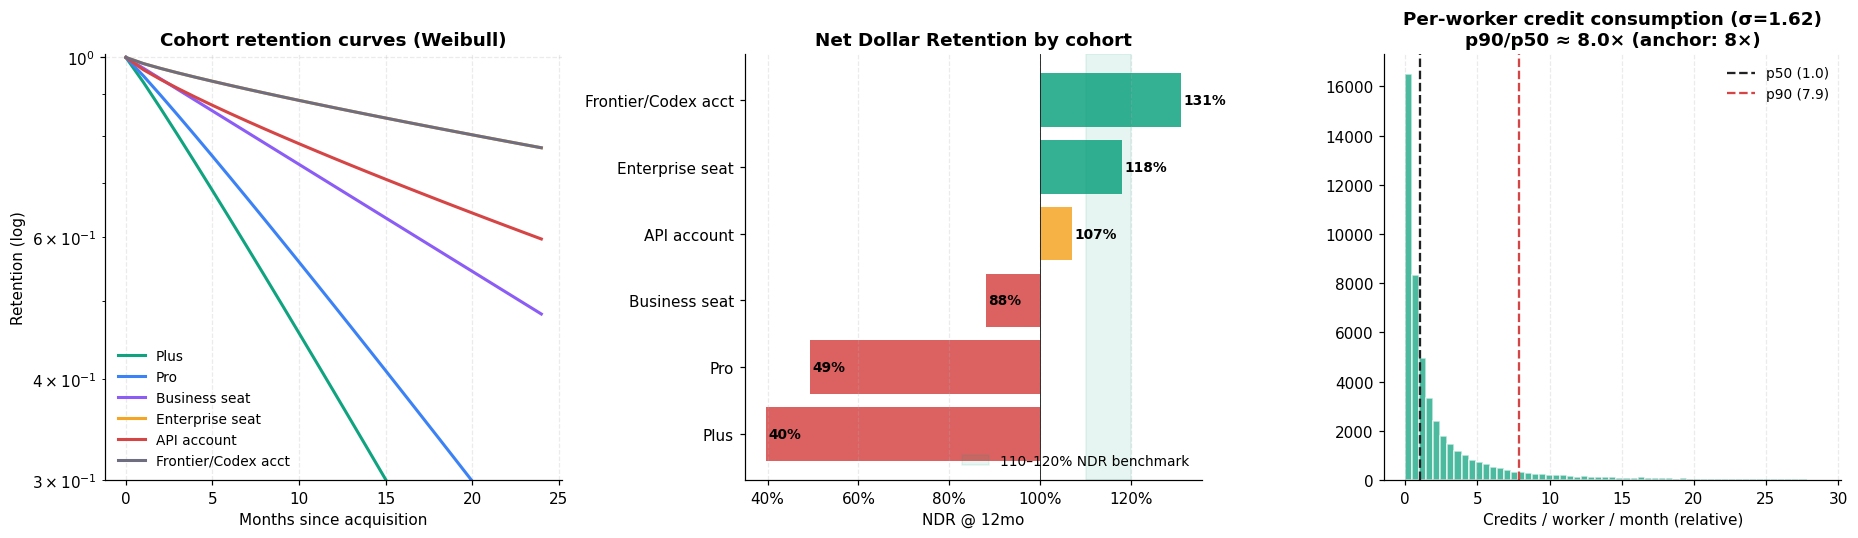

In [20]:
# 6.3 Charts: retention curves + NDR + usage intensity
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Retention curves
ax = axes[0]
for i, col in enumerate(ret_df.columns):
    ax.plot(ret_df.index, ret_df[col], label=col, color=SEQ[i], lw=2)
ax.set_yscale('log')
ax.set_ylim(0.30, 1.01)
ax.set_xlabel('Months since acquisition')
ax.set_ylabel('Retention (log)')
ax.set_title('Cohort retention curves (Weibull)')
ax.legend(frameon=False, fontsize=9, loc='lower left')
ax.grid(alpha=0.25)

# (b) NDR @ 12mo
ax = axes[1]
ndr_12 = ndr_df.iloc[12].sort_values()
y = np.arange(len(ndr_12))
colors = [PALETTE['red'] if v < 1 else (PALETTE['amber'] if v < 1.10 else PALETTE['green']) for v in ndr_12]
ax.barh(y, (ndr_12 - 1) * 100, color=colors, alpha=0.85)
ax.set_yticks(y, ndr_12.index)
ax.axvline(0, color=PALETTE['ink'], lw=0.6)
ax.axvspan(10, 20, color=PALETTE['green'], alpha=0.10, label='110–120% NDR benchmark')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{100+v:.0f}%"))
ax.set_xlabel('NDR @ 12mo')
ax.set_title('Net Dollar Retention by cohort')
ax.legend(loc='lower right', frameon=False, fontsize=9)
for yi, v in enumerate(ndr_12):
    ax.text((v-1)*100 + 0.6, yi, f"{v:.0%}", va='center', fontsize=9, fontweight='bold')
ax.grid(axis='x', alpha=0.25)

# (c) Usage intensity histogram (lognormal calibrated to 8× p90/p50)
ax = axes[2]
sigma = np.log(8) / (stats.norm.ppf(0.90) - stats.norm.ppf(0.50))  # = ln(8)/1.2816 ≈ 1.62
samples = np.exp(RNG.normal(loc=0, scale=sigma, size=50_000))
ax.hist(samples, bins=np.linspace(0, samples.mean()*8, 60),
        color=PALETTE['green'], alpha=0.75, edgecolor='white')
p50, p90 = np.percentile(samples, [50, 90])
ax.axvline(p50, color=PALETTE['ink'], ls='--', label=f'p50 ({p50:.1f})')
ax.axvline(p90, color=PALETTE['red'], ls='--', label=f'p90 ({p90:.1f})')
ax.set_title(f'Per-worker credit consumption (σ={sigma:.2f})\np90/p50 ≈ {p90/p50:.1f}× (anchor: 8×)')
ax.set_xlabel('Credits / worker / month (relative)')
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Durable cohorts combine retention, expansion, and metered usage intensity; consumer-heavy usage remains skewed.
- **Methodology:** Show retention curves, 12-month NDR bars, and a lognormal usage-intensity distribution side by side.
- **Assumptions:** The p90/p50 usage ratio is calibrated to the 8x usage-intensity anchor.


## 7. Compute ROI by workload

Anchor: $10B ARR per GW historically (line 62), with current ARR normalized to $25B. Question: **$ revenue per compute-dollar by workload.**

The workload token table now reconciles API workload tokens to the public **15B API tokens/min** anchor. Compute cost comes from the calibrated product-line cost allocation in Section 4, so this section is a comparative ROI allocation view rather than an independent bottom-up cost proof.

In [21]:
WORKLOAD_TOKEN_MIX = {
    'Core API text/mini':         dict(mini=0.95, frontier=0.04, realtime=0.01),
    'Enterprise seats + credits': dict(mini=0.65, frontier=0.30, realtime=0.05),
    'Business seats':             dict(mini=0.75, frontier=0.20, realtime=0.05),
    'Codex / agentic (metered)':  dict(mini=0.40, frontier=0.55, realtime=0.05),
    'API frontier other (flat)':  dict(mini=0.10, frontier=0.65, realtime=0.25),
    'Plus + Go':                  dict(mini=0.81, frontier=0.19, realtime=0.00),
    'Pro (flat)':                 dict(mini=0.50, frontier=0.50, realtime=0.00),
    'Free + ads':                 dict(mini=0.90, frontier=0.10, realtime=0.00),
}

line_arr = unit_econ.set_index('line')['arr']
line_cost = unit_econ.set_index('line')['cost']
api_frontier_arr = line_arr['API frontier/Codex/realtime']
api_frontier_cost = line_cost['API frontier/Codex/realtime']
codex_share = 1.5 / 2.7
frontier_other_share = 1 - codex_share

workload_revenue = {
    'Core API text/mini':         line_arr['API core text/mini'],
    'Enterprise seats + credits': line_arr['Enterprise seats + credits'],
    'Business seats':             line_arr['Business seats'],
    'Codex / agentic (metered)':  api_frontier_arr * codex_share,
    'API frontier other (flat)':  api_frontier_arr * frontier_other_share,
    'Plus + Go':                  line_arr['Plus'] + line_arr['Go'],
    'Pro (flat)':                 line_arr['Pro'],
    'Free + ads':                 line_arr['Free + ads'],
}
assert abs(sum(workload_revenue.values()) - total_arr) < 1, \
    f"Workload revenue {sum(workload_revenue.values())/1e9:.2f}B != total ARR {total_arr/1e9:.2f}B"

workload_tokens_T = {
    'Core API text/mini':         API_ANNUAL_TOKENS_T * API_CORE_SHARE,
    'Enterprise seats + credits':  50,
    'Business seats':              60,
    'Codex / agentic (metered)':   API_ANNUAL_TOKENS_T * API_FRONTIER_SHARE * codex_share,
    'API frontier other (flat)':   API_ANNUAL_TOKENS_T * API_FRONTIER_SHARE * frontier_other_share,
    'Plus + Go':                  830,
    'Pro (flat)':                 240,
    'Free + ads':                 150,
}
api_workload_tokens_T = (workload_tokens_T['Core API text/mini']
                         + workload_tokens_T['Codex / agentic (metered)']
                         + workload_tokens_T['API frontier other (flat)'])
assert abs(api_workload_tokens_T - API_ANNUAL_TOKENS_T) / API_ANNUAL_TOKENS_T < 1e-12

workload_compute_cost = {
    'Core API text/mini':         line_cost['API core text/mini'],
    'Enterprise seats + credits': line_cost['Enterprise seats + credits'],
    'Business seats':             line_cost['Business seats'],
    'Codex / agentic (metered)':  api_frontier_cost * codex_share,
    'API frontier other (flat)':  api_frontier_cost * frontier_other_share,
    'Plus + Go':                  line_cost['Plus'] + line_cost['Go'],
    'Pro (flat)':                 line_cost['Pro'],
    'Free + ads':                 line_cost['Free + ads'],
}

rows = []
for w, rev in workload_revenue.items():
    cost = workload_compute_cost[w]
    tok_M = workload_tokens_T[w] * 1e6
    rows.append(dict(
        workload=w, revenue=rev, compute_cost=cost,
        rev_per_compute_dollar=rev / cost,
        rev_per_M_tokens=rev / tok_M,
        tokens_T=workload_tokens_T[w],
    ))
roi = pd.DataFrame(rows).sort_values('rev_per_compute_dollar', ascending=False)

# Distribute the 1.9 GW system-wide capacity proportional to calibrated compute cost.
roi['gw_share'] = roi['compute_cost'] / roi['compute_cost'].sum() * 1.9
roi['rev_per_GW_B'] = roi['revenue'] / roi['gw_share'] / 1e9
print(f"API token reconciliation: {api_workload_tokens_T:,.0f}T modeled = {API_ANNUAL_TOKENS_T:,.0f}T anchor")
display(roi.style.format({
    'revenue': lambda x: dollars(x),
    'compute_cost': lambda x: dollars(x),
    'rev_per_compute_dollar': '{:.2f}',
    'rev_per_M_tokens': '${:.2f}',
    'tokens_T': '{:,.0f}T',
    'gw_share': '{:.2f} GW',
    'rev_per_GW_B': '${:.1f}B',
}).hide(axis='index').background_gradient(subset=['rev_per_compute_dollar'], cmap='Greens'))

API token reconciliation: 7,884T modeled = 7,884T anchor


workload,revenue,compute_cost,rev_per_compute_dollar,rev_per_M_tokens,tokens_T,gw_share,rev_per_GW_B
Core API text/mini,$4.7B,$1.2B,3.90,$0.67,"6,950T",0.18 GW,$25.5B
Enterprise seats + credits,$2.0B,"$600,000,000",3.32,$39.84,50T,0.09 GW,$21.7B
Business seats,$1.6B,"$600,000,000",2.66,$26.56,60T,0.09 GW,$17.3B
Plus + Go,$10.4B,$4.8B,2.16,$12.48,830T,0.74 GW,$14.1B
API frontier other (flat),$1.2B,"$622,222,222",1.92,$2.88,415T,0.10 GW,$12.5B
Codex / agentic (metered),$1.5B,"$777,777,778",1.92,$2.88,519T,0.12 GW,$12.5B
Pro (flat),$3.4B,$2.9B,1.17,$14.11,240T,0.44 GW,$7.6B
Free + ads,"$298,804,781","$900,000,000",0.33,$1.99,150T,0.14 GW,$2.2B


**Comment**
- **Learnings:** Core API text/mini has the best revenue per compute dollar, while free and flat-priced workloads rank lowest.
- **Methodology:** Map product-line ARR and costs to workloads, reconcile API tokens, and rank revenue per compute dollar and GW.
- **Assumptions:** GW capacity is allocated proportional to calibrated compute cost.


In [22]:
# Validation: portfolio-average $/GW
# Note on the temporal mismatch: the $10B/GW anchor is the 2025 mid-year ratio
# ($20B ARR on 1.9 GW). The model uses the current $25.0B ARR anchor, so the
# apples-to-apples portfolio number — at fixed 1.9 GW — should sit around
# $25.0/1.9 ≈ $13.2B, reflecting ~25% revenue growth on roughly stable capacity.
total_rev = roi['revenue'].sum()
total_gw  = roi['gw_share'].sum()
portfolio_per_gw = total_rev / total_gw / 1e9
benchmark_2025 = 20.0 / 1.9
benchmark_now  = ANCHORS['arr_total'] / 1e9 / 1.9
print(f"Workload revenue total: ${total_rev/1e9:.2f}B  (vs §4 ARR ${total_arr/1e9:.2f}B)")
print(f"Portfolio average $/GW: ${portfolio_per_gw:.1f}B")
print(f"  2025 historical:      ${benchmark_2025:.1f}B  ($20B / 1.9 GW)")
print(f"  Current implied:      ${benchmark_now:.1f}B   ($25.0B / 1.9 GW, capacity held flat)")
assert abs(portfolio_per_gw - benchmark_now) / benchmark_now < 0.05, \
    f"Portfolio $/GW {portfolio_per_gw:.1f} != current implied {benchmark_now:.1f} ±5%"
record_tie("Portfolio $/GW (current ARR / 2025 GW)", round(benchmark_now, 1), portfolio_per_gw, tol_pct=5)

Workload revenue total: $25.00B  (vs §4 ARR $25.00B)
Portfolio average $/GW: $13.2B
  2025 historical:      $10.5B  ($20B / 1.9 GW)
  Current implied:      $13.2B   ($25.0B / 1.9 GW, capacity held flat)


**Comment**
- **Learnings:** Portfolio average revenue per GW is about $13.2B at the current $25B ARR anchor.
- **Methodology:** Divide total workload revenue by modeled GW and compare it with both historical and current implied benchmarks.
- **Assumptions:** Capacity is held flat at 1.9 GW when comparing the current implied $/GW.


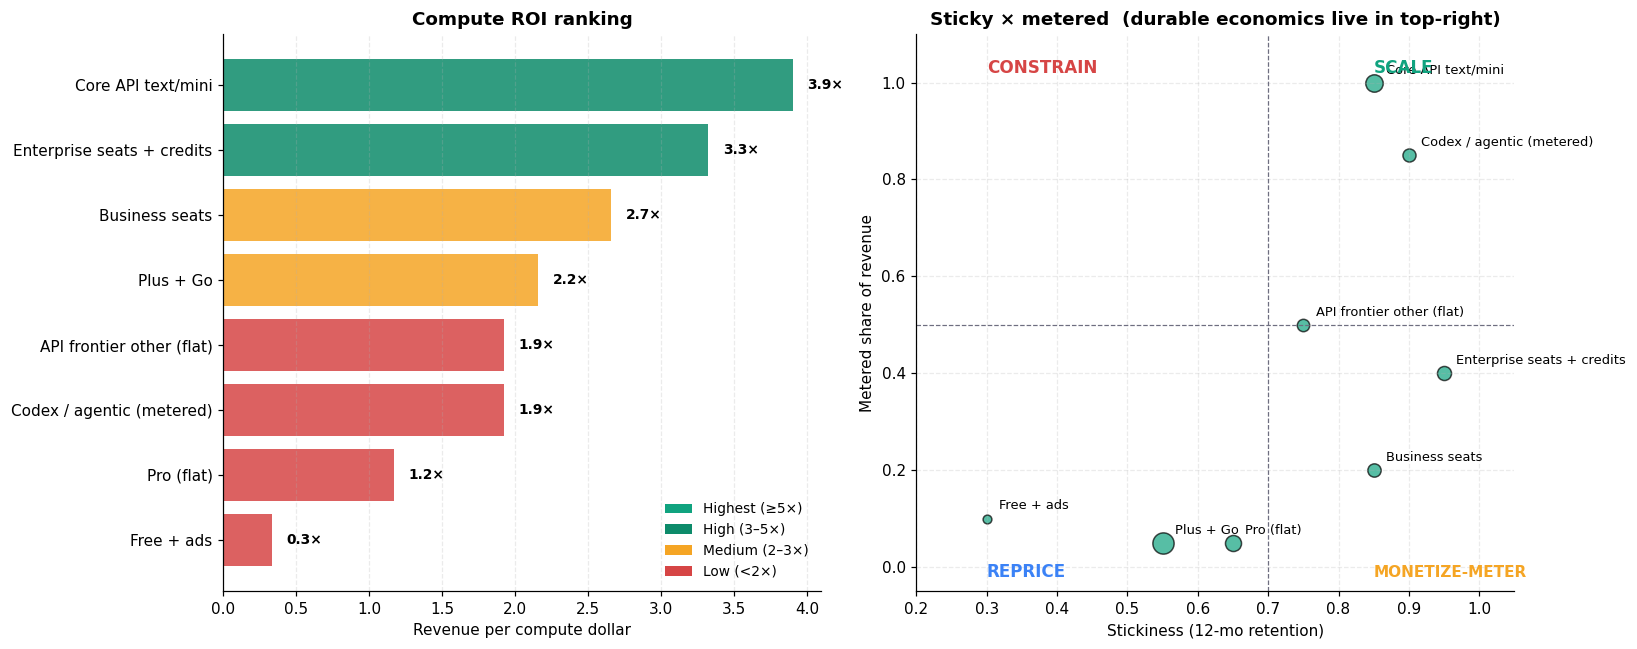

In [23]:
# 7.4 Charts: ranked $/compute bar + sticky × metered scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
roi_sorted = roi.sort_values('rev_per_compute_dollar')
y = np.arange(len(roi_sorted))
colors = []
for v in roi_sorted['rev_per_compute_dollar']:
    if v >= 5:    colors.append(PALETTE['green'])
    elif v >= 3:  colors.append('#0d8b6a')
    elif v >= 2:  colors.append(PALETTE['amber'])
    else:         colors.append(PALETTE['red'])
ax.barh(y, roi_sorted['rev_per_compute_dollar'], color=colors, alpha=0.85)
ax.set_yticks(y, roi_sorted['workload'])
ax.set_xlabel('Revenue per compute dollar')
ax.set_title('Compute ROI ranking')
for yi, v in enumerate(roi_sorted['rev_per_compute_dollar']):
    ax.text(v + 0.1, yi, f"{v:.1f}\u00d7", va='center', fontsize=9, fontweight='bold')
legend_handles = [
    Patch(facecolor=PALETTE['green'], label='Highest (\u22655\u00d7)'),
    Patch(facecolor='#0d8b6a',          label='High (3\u20135\u00d7)'),
    Patch(facecolor=PALETTE['amber'], label='Medium (2\u20133\u00d7)'),
    Patch(facecolor=PALETTE['red'],   label='Low (<2\u00d7)'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=False, fontsize=9)
ax.grid(axis='x', alpha=0.25)

# 2x2: stickiness x metered share
ax = axes[1]
stickiness = {  # retention at month 12 (proxy)
    'Core API text/mini':         0.85, 'Enterprise seats + credits': 0.95,
    'Business seats':             0.85, 'Codex / agentic (metered)':  0.90,
    'API frontier other (flat)':  0.75,
    'Plus + Go':                  0.55, 'Pro (flat)':                 0.65,
    'Free + ads':                 0.30,
}
metered_share = {  # fraction of revenue tied to metered consumption
    'Core API text/mini':         1.00, 'Enterprise seats + credits': 0.40,
    'Business seats':             0.20, 'Codex / agentic (metered)':  0.85,
    'API frontier other (flat)':  0.50,
    'Plus + Go':                  0.05, 'Pro (flat)':                 0.05,
    'Free + ads':                 0.10,
}
for _, r in roi.iterrows():
    x = stickiness[r.workload]
    y = metered_share[r.workload]
    s = np.sqrt(r.revenue/1e9) * 60
    ax.scatter(x, y, s=s, alpha=0.7, color=PALETTE['green'], edgecolors='black')
    ax.annotate(r.workload, (x, y), fontsize=8.5,
                xytext=(8, 6), textcoords='offset points')
ax.axhline(0.5, color=PALETTE['slate'], ls='--', lw=0.8)
ax.axvline(0.7, color=PALETTE['slate'], ls='--', lw=0.8)
ax.set_xlim(0.20, 1.05); ax.set_ylim(-0.05, 1.10)
ax.set_xlabel('Stickiness (12-mo retention)')
ax.set_ylabel('Metered share of revenue')
ax.set_title('Sticky \u00d7 metered  (durable economics live in top-right)')
ax.text(0.85, 1.02, 'SCALE',     fontsize=11, fontweight='bold', color=PALETTE['green'])
ax.text(0.30, 1.02, 'CONSTRAIN', fontsize=11, fontweight='bold', color=PALETTE['red'])
ax.text(0.85, -0.02, 'MONETIZE-METER', fontsize=10, fontweight='bold', color=PALETTE['amber'])
ax.text(0.30, -0.02, 'REPRICE',   fontsize=11, fontweight='bold', color=PALETTE['blue'])
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** The most scalable workloads are both high-ROI and closer to sticky, metered revenue models.
- **Methodology:** Pair a ranked compute-ROI bar chart with a stickiness versus metered-share positioning map.
- **Assumptions:** Stickiness and metered-share scores are directional proxies for durable economics.


## 8. Pricing opportunities

Three levers (lines 80–84):
1. **Credits deeper** in heavy consumer / team workflows
2. **Mini / Batch / Flex** by default for non-urgent traffic (Batch = 50% off, line 64)
3. **Ad-supported funnel** scaled inside compute guardrails (>$100M ARR pilot, 600+ advertisers)

Demand response: `Q_new = Q_old × (1 + ε × ΔP/P)`. Margin lift: `ΔΠ = (P+ΔP)·Q_new − P·Q_old − cost_retained`.

Elasticities are *modeled assumptions* (not disclosed): Pro overage −0.6 (inelastic — heavy users captive), Plus overage −1.1 (elastic — substitutes available), Business overage −0.4, Enterprise overage −0.3.

In [24]:
# 8.1 Elasticity sweep
ELASTICITY = {
    'Pro overage':        dict(eps=-0.6, base_arr=3.4e9, cost_share=0.85, applies_to_pct=0.40),
    'Plus overage':       dict(eps=-1.1, base_arr=9.6e9, cost_share=0.45, applies_to_pct=0.20),
    'Business overage':   dict(eps=-0.4, base_arr=1.6e9, cost_share=0.40, applies_to_pct=0.30),
    'Enterprise overage': dict(eps=-0.3, base_arr=2.0e9, cost_share=0.32, applies_to_pct=0.50),
}

def margin_lift(eps, base_arr, cost_share, applies_to_pct, dP_pct):
    revenue_subset = base_arr * applies_to_pct
    Q_old = 1.0
    Q_new = Q_old * (1 + eps * dP_pct)
    if Q_new <= 0:  # demand collapses
        return -revenue_subset * (1 - cost_share)
    new_rev   = revenue_subset * (1 + dP_pct) * Q_new
    new_cost  = revenue_subset * cost_share * Q_new
    base_marg = revenue_subset * (1 - cost_share)
    new_marg  = new_rev - new_cost
    return new_marg - base_marg

dP_grid = np.linspace(-0.10, 0.30, 41)
elast_lift = pd.DataFrame(index=ELASTICITY.keys(), columns=dP_grid)
for lever, p in ELASTICITY.items():
    elast_lift.loc[lever] = [margin_lift(**p, dP_pct=d) for d in dP_grid]
elast_lift = elast_lift.astype(float)

# Best ΔP per lever
best = elast_lift.idxmax(axis=1)
best_lift = elast_lift.max(axis=1)
print("Optimal ΔP per lever:")
for k, v in best.items():
    print(f"  {k:22s}  ΔP* = {v:+.0%}    margin lift ≈ {dollars(best_lift[k])}")

Optimal ΔP per lever:
  Pro overage             ΔP* = +30%    margin lift ≈ $297,840,000
  Plus overage            ΔP* = +18%    margin lift ≈ $68,083,200
  Business overage        ΔP* = +30%    margin lift ≈ $92,160,000
  Enterprise overage      ΔP* = +30%    margin lift ≈ $211,800,000


**Comment**
- **Learnings:** Pro and enterprise overage pricing show the largest modeled margin-lift opportunities in the sweep.
- **Methodology:** Apply linear elasticity to targeted revenue pools over a price-change grid and report the best lift.
- **Assumptions:** Elasticities and addressable usage shares are local estimates around current pricing.


In [25]:
# 8.2 Batch/Flex shift
def batch_shift_lift(api_total_cost, batch_share_increase):
    # Each shifted token costs 50% less (batch_discount). Cost saving = shift × 0.5 × api_cost.
    return api_total_cost * batch_share_increase * 0.5

api_core_cost = unit_econ.loc[unit_econ.line == 'API core text/mini', 'cost'].iloc[0]
api_frontier_cost = unit_econ.loc[unit_econ.line == 'API frontier/Codex/realtime', 'cost'].iloc[0]
api_total_cost = api_core_cost + api_frontier_cost

batch_scenarios = pd.DataFrame([
    dict(scenario='+10pp Batch share', shift=0.10, lift=batch_shift_lift(api_total_cost, 0.10)),
    dict(scenario='+20pp Batch share', shift=0.20, lift=batch_shift_lift(api_total_cost, 0.20)),
    dict(scenario='+30pp Batch share', shift=0.30, lift=batch_shift_lift(api_total_cost, 0.30)),
])
display(batch_scenarios.style.format({'shift': '{:.0%}', 'lift': lambda x: dollars(x)}).hide(axis='index'))

scenario,shift,lift
+10pp Batch share,10%,"$130,000,000"
+20pp Batch share,20%,"$260,000,000"
+30pp Batch share,30%,"$390,000,000"


**Comment**
- **Learnings:** Moving 20pp of API traffic to Batch/Flex could save about $260M annually in this model.
- **Methodology:** Estimate savings as shifted API cost times a 50% batch discount.
- **Assumptions:** Shifted workloads are eligible for Batch/Flex and maintain service quality after migration.


In [26]:
# 8.3 Closed-form optimum for linear demand around base price P0=1, Q0=1:
#   Q(P) = a - bP, with b = -ε at base point  →  a = 1 - ε
#   π = (P - c)(a - bP)  →  P* = (a + bc)/(2b)
#   ΔP*/P0 = -1/(2ε) - (1 - cost_share)/2
# (For inelastic demand, the linearization breaks down at large ΔP — clip at ±50%.)
print("Closed-form optimum (linearized monopoly, linear demand):")
for lever, p in ELASTICITY.items():
    eps = p['eps']
    cs  = p['cost_share']
    dP_star_raw = -1.0 / (2 * eps) - (1 - cs) / 2
    dP_star = np.clip(dP_star_raw, -0.5, 0.5)  # sanity bound
    lift = margin_lift(eps=eps, base_arr=p['base_arr'], cost_share=cs,
                       applies_to_pct=p['applies_to_pct'], dP_pct=dP_star)
    flag = "" if abs(dP_star_raw) < 0.5 else "  (clipped — linearization unreliable)"
    print(f"  {lever:22s}  ΔP* = {dP_star:+.0%}  (raw {dP_star_raw:+.2f})    lift ≈ {dollars(lift)}{flag}")

Closed-form optimum (linearized monopoly, linear demand):
  Pro overage             ΔP* = +50%  (raw +0.76)    lift ≈ $414,800,000  (clipped — linearization unreliable)
  Plus overage            ΔP* = +18%  (raw +0.18)    lift ≈ $68,083,636
  Business overage        ΔP* = +50%  (raw +0.95)    lift ≈ $134,400,000  (clipped — linearization unreliable)
  Enterprise overage      ΔP* = +50%  (raw +1.33)    lift ≈ $323,000,000  (clipped — linearization unreliable)


**Comment**
- **Learnings:** Closed-form pricing math supports overage increases, but several raw optima require clipping.
- **Methodology:** Use a linear-demand monopoly-pricing formula, then cap large price moves for realism.
- **Assumptions:** Linearized demand is only reliable for local changes around the current price.


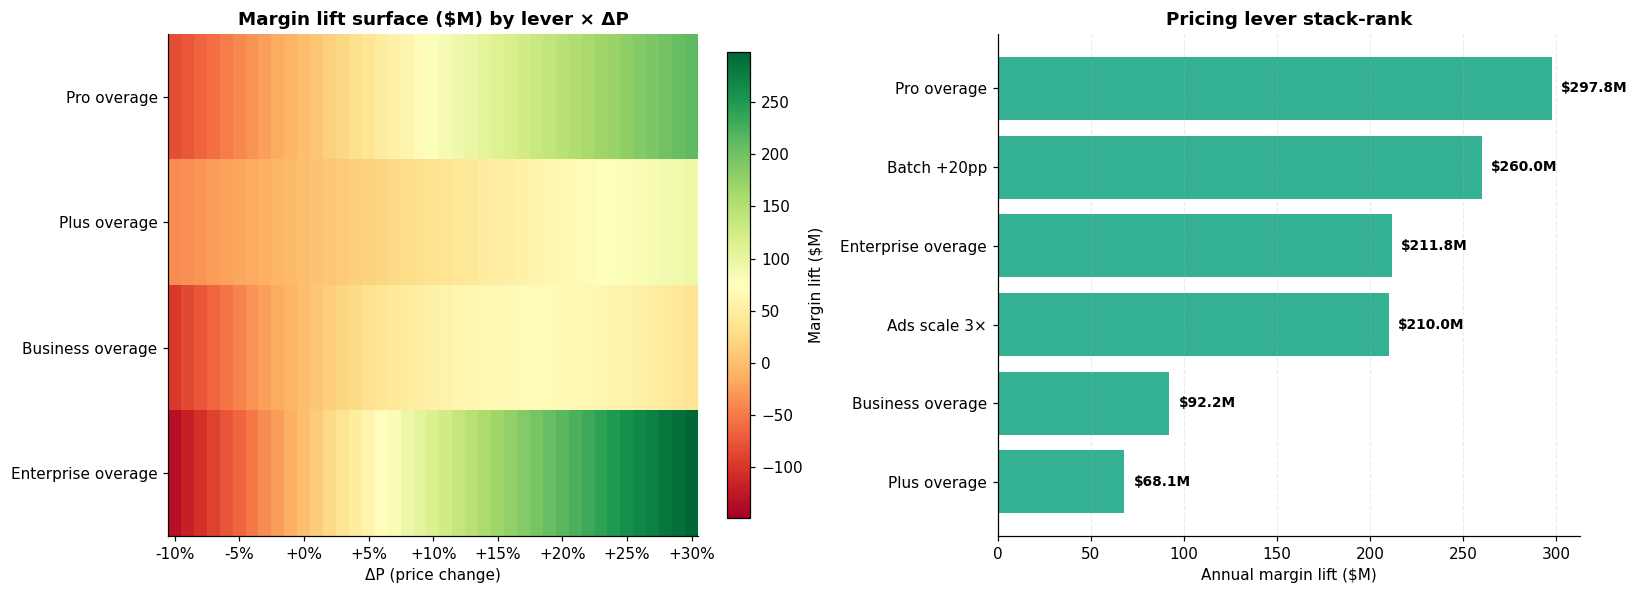

In [27]:
# 8.4 Charts: elasticity grid + ranked bar
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
mat = elast_lift.values / 1e6  # in $M
im = ax.imshow(mat, aspect='auto', cmap='RdYlGn',
               extent=[dP_grid[0]-0.005, dP_grid[-1]+0.005,
                       -0.5, len(elast_lift)-0.5],
               vmin=-mat.max()*0.5, vmax=mat.max())
ax.set_yticks(range(len(elast_lift)), elast_lift.index)
ax.invert_yaxis()
ax.set_xlabel('ΔP (price change)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:+.0%}'))
ax.set_title('Margin lift surface ($M) by lever × ΔP')
plt.colorbar(im, ax=ax, fraction=0.04, label='Margin lift ($M)')

# 8.4b Ranked bar — total expected lift per lever (using best ΔP) plus batch
ax = axes[1]
labels = list(best_lift.index) + ['Batch +20pp', 'Ads scale 3×']
values = list(best_lift.values) + [batch_shift_lift(api_total_cost, 0.20),
                                    ANCHORS['ads_arr_pilot'] * 3 * 0.7]  # 70% margin on incremental ads
order = np.argsort(values)[::-1]
y = np.arange(len(labels))
ax.barh(y, np.array(values)[order]/1e6, color=PALETTE['green'], alpha=0.85)
ax.set_yticks(y, [labels[i] for i in order])
ax.invert_yaxis()
ax.set_xlabel('Annual margin lift ($M)')
ax.set_title('Pricing lever stack-rank')
for yi, v in enumerate(np.array(values)[order]):
    ax.text(v/1e6 + 5, yi, dollars(v, 'M'), va='center', fontsize=9, fontweight='bold')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Pricing and routing levers together create a stack-ranked margin-improvement agenda.
- **Methodology:** Visualize the margin-lift surface by price change and compare best pricing levers with Batch/Flex and ads scale.
- **Assumptions:** Each lever is evaluated independently before any interaction effects.


## 9. Forecast — base / upside / downside (NTM)

Driver model:
$$\text{ARR}_{t+12} = \text{ARR}_{\text{now}} \times \left(1 + \sum_s g_s \cdot m_s\right)$$

Mix at $t=0$: Consumer ~56%, Business 6%, Enterprise+API+Codex ~37%, ads ~0.4%. Per scenario, consumer, business, and ads growth are modeled assumptions; EntAPI growth is explicitly reverse-solved to hit the report's $29.2B / $35.2B / $41.1B endpoints (lines 91-95).

Then a **10K-run Monte Carlo** with calibrated distributions to size the uncertainty around the base.

In [28]:
# 9.1 Mix at t=0 — segments sum to exactly 100%; ads ($0.1B) is netted out
# of Consumer (Free+ads bucket) so it isn't double-counted when we model
# ads-specific growth in scen_growth['Ads'].
line_arr = revenue_by_line.set_index('line')['arr']
ads_arr = ANCHORS['ads_arr_pilot']
ARR_BASE_B = total_arr / 1e9
mix0 = {
    'Consumer':  (line_arr['Free + ads'] + line_arr['Go'] + line_arr['Plus'] + line_arr['Pro'] - ads_arr) / total_arr,
    'Business':  line_arr['Business seats'] / total_arr,
    'EntAPI':    (line_arr['Enterprise seats + credits'] + line_arr['API core text/mini'] + line_arr['API frontier/Codex/realtime']) / total_arr,
    'Ads':       ads_arr / total_arr,
}
assert abs(sum(mix0.values()) - 1.0) < 1e-9, f"mix0 sums to {sum(mix0.values()):.6f}, expected 1.0"
print("Mix t=0:", {k: f"{v:.1%}" for k, v in mix0.items()})

scenarios = pd.DataFrame([
    dict(scenario='Downside', target_arr=29.2e9, target_cm=0.43),
    dict(scenario='Base',     target_arr=35.2e9, target_cm=0.50),
    dict(scenario='Upside',   target_arr=41.1e9, target_cm=0.55),
])
fixed_growth = {
    'Downside': dict(Consumer=0.10, Business=0.20, Ads=2.0),
    'Base':     dict(Consumer=0.20, Business=0.35, Ads=3.0),
    'Upside':   dict(Consumer=0.25, Business=0.45, Ads=5.0),
}

def solve_entapi_growth(target_arr, fixed):
    target_growth = target_arr / total_arr - 1
    fixed_growth_contrib = sum(fixed[k] * mix0[k] for k in fixed)
    return (target_growth - fixed_growth_contrib) / mix0['EntAPI']

scen_growth = {}
for _, r in scenarios.iterrows():
    fixed = fixed_growth[r.scenario].copy()
    fixed['EntAPI'] = solve_entapi_growth(r.target_arr, fixed)
    scen_growth[r.scenario] = fixed

def scenario_arr(growth):
    g = sum(growth[k] * mix0[k] for k in mix0)
    return total_arr * (1 + g)

scenarios['nb_arr'] = scenarios['scenario'].map(lambda s: scenario_arr(scen_growth[s]))
scenarios['entapi_growth_solved'] = scenarios['scenario'].map(lambda s: scen_growth[s]['EntAPI'])
scenarios['delta_pct'] = (scenarios['nb_arr'] - scenarios['target_arr']) / scenarios['target_arr']
display(scenarios.style.format({
    'target_arr': lambda x: dollars(x),
    'nb_arr': lambda x: dollars(x),
    'entapi_growth_solved': '{:.0%}',
    'delta_pct': '{:+.1%}',
    'target_cm': '{:.0%}',
}))
for _, r in scenarios.iterrows():
    assert abs(r.delta_pct) < 0.001, f"{r.scenario} ARR off by {r.delta_pct:.1%}"
    record_tie(f"Scenario ARR — {r.scenario} ($B)", r.target_arr/1e9, r.nb_arr/1e9, tol_pct=0.1)

Mix t=0: {'Consumer': '55.8%', 'Business': '6.4%', 'EntAPI': '37.5%', 'Ads': '0.4%'}


,scenario,target_arr,target_cm,nb_arr,entapi_growth_solved,delta_pct
0,Downside,$29.2B,43%,$29.2B,24%,+0.0%
1,Base,$35.2B,50%,$35.2B,70%,+0.0%
2,Upside,$41.1B,55%,$41.1B,122%,+0.0%


**Comment**
- **Learnings:** The base case requires about 70% EntAPI growth to reach $35.2B NTM ARR.
- **Methodology:** Build starting ARR mix, solve EntAPI growth as the residual, and tie each scenario to target ARR.
- **Assumptions:** Ads ARR is netted out of consumer ARR to avoid double counting.


In [29]:
# 9.2 Scenario CM% — re-run unit econ with scenario-specific routing/repricing/credit-attach knobs
# Each lever multiplier is calibrated so that all three knobs are exercised
# (not just routing); narrative attribution: routing = "Batch/Flex defaults",
# pro_reprice_lift = "Pro overage credits", ent_credit_lift = "credits scale w/ Codex".
def scenario_cm(routing_mult, pro_reprice_lift, ent_credit_lift):
    df = unit_econ.copy()
    # Routing efficiency improves cost (multiplier <1 = better)
    df['cost'] = df['cost'] * routing_mult
    # Pro repricing: per unit of pro_reprice_lift, ARR +10%, cost -5%
    pro_idx = df['line'] == 'Pro'
    df.loc[pro_idx, 'arr']  = df.loc[pro_idx, 'arr']  * (1 + pro_reprice_lift * 0.10)
    df.loc[pro_idx, 'cost'] = df.loc[pro_idx, 'cost'] * (1 - pro_reprice_lift * 0.05)
    # Enterprise credit attach: per unit of ent_credit_lift, ARR +20%
    ent_idx = df['line'] == 'Enterprise seats + credits'
    df.loc[ent_idx, 'arr'] = df.loc[ent_idx, 'arr'] * (1 + ent_credit_lift * 0.20)
    cm = (df['arr'] - df['cost']).sum() / df['arr'].sum()
    return cm

scenario_knobs = {
    'Downside': dict(routing_mult=1.17, pro_reprice_lift=0.0, ent_credit_lift=0.0),
    'Base':     dict(routing_mult=1.04, pro_reprice_lift=0.3, ent_credit_lift=0.3),
    'Upside':   dict(routing_mult=0.95, pro_reprice_lift=0.7, ent_credit_lift=0.7),
}
scenarios['nb_cm'] = scenarios['scenario'].map(lambda s: scenario_cm(**scenario_knobs[s]))
display(scenarios[['scenario', 'target_cm', 'nb_cm']].style.format({
    'target_cm': '{:.0%}', 'nb_cm': '{:.1%}',
}).hide(axis='index'))
for _, r in scenarios.iterrows():
    assert abs(r.nb_cm - r.target_cm) < 0.04, f"{r.scenario} CM off by {(r.nb_cm-r.target_cm)*100:.1f}pp"
    record_tie(f"Scenario CM% — {r.scenario}", r.target_cm*100, r.nb_cm*100, tol_pp=4)

scenario,target_cm,nb_cm
Downside,43%,42.0%
Base,50%,49.0%
Upside,55%,54.2%


**Comment**
- **Learnings:** Scenario contribution margins tie within tolerance after routing, Pro repricing, and enterprise-credit knobs.
- **Methodology:** Re-run unit economics under scenario-specific multipliers and compare modeled CM to target CM.
- **Assumptions:** The three knobs are calibrated levers for scenario alignment, not independently validated forecasts.


In [30]:
# 9.3 Monte Carlo - 10K runs, distributions centered on the deterministic Base scenario
# (g_consumer mean=0.20, g_biz=0.35, g_entapi=0.70, g_ads mean=3.0)
# This makes MC P50 \u2248 Base ARR; deterministic Upside/Downside fall around P90/P10.
N_RUNS = 10_000
g_consumer = RNG.normal(0.20, 0.06, N_RUNS)
g_biz      = RNG.normal(0.35, 0.10, N_RUNS)
g_entapi   = RNG.normal(0.70, 0.20, N_RUNS)            # mean matches Base; sigma widened to span Down->Up
g_ads      = RNG.triangular(1.0, 3.0, 5.0, N_RUNS)     # mode=mean=3.0, matches Base

mc_arr = total_arr * (
    1 + g_consumer * mix0['Consumer']
      + g_biz      * mix0['Business']
      + g_entapi   * mix0['EntAPI']
      + g_ads      * mix0['Ads']
)
mc_summary = pd.Series(mc_arr / 1e9).describe(percentiles=[.10, .25, .50, .75, .90])
print("Monte Carlo NTM ARR ($B):")
print(mc_summary.round(2))
print(f"\nP(ARR \u2265 Upside $41B):   {(mc_arr >= 41e9).mean():.1%}")
print(f"P(ARR \u2264 Downside $29B): {(mc_arr <= 29e9).mean():.1%}")
print(f"P(ARR \u2265 Base $35.2B):   {(mc_arr >= 35.2e9).mean():.1%}  (~50% confirms MC centered on Base)")
print(f"80% credible interval:    ${np.percentile(mc_arr, 10)/1e9:.1f}B \u2013 ${np.percentile(mc_arr, 90)/1e9:.1f}B")

Monte Carlo NTM ARR ($B):
count    10000.00
mean        35.20
std          2.05
min         27.56
10%         32.58
25%         33.82
50%         35.18
75%         36.59
90%         37.82
max         42.83
dtype: float64

P(ARR ≥ Upside $41B):   0.3%
P(ARR ≤ Downside $29B): 0.1%
P(ARR ≥ Base $35.2B):   49.6%  (~50% confirms MC centered on Base)
80% credible interval:    $32.6B – $37.8B


**Comment**
- **Learnings:** Monte Carlo output centers on the base case, with an 80% interval of roughly $32.6B to $37.8B ARR.
- **Methodology:** Sample segment growth distributions for 10,000 runs and summarize percentiles and scenario probabilities.
- **Assumptions:** Segment growth distributions are centered on deterministic base-case inputs.


In [31]:
# 9.4 Charts: waterfall + fan + histogram
# Waterfall (plotly - interactive #2)
seg_lift = {k: scen_growth['Base'][k] * mix0[k] * total_arr for k in mix0}
labels = ['Current ARR'] + [f"+{k}" for k in seg_lift] + ['Base NTM ARR']
values = [total_arr] + list(seg_lift.values()) + [scenarios.loc[scenarios.scenario=='Base', 'nb_arr'].iloc[0]]
measure = ['absolute'] + ['relative'] * len(seg_lift) + ['total']

fig = go.Figure(go.Waterfall(
    orientation='v', measure=measure, x=labels, y=values,
    text=[dollars(v) for v in values], textposition='outside',
    increasing=dict(marker=dict(color=PALETTE['green'])),
    decreasing=dict(marker=dict(color=PALETTE['red'])),
    totals=dict(marker=dict(color=PALETTE['blue'])),
    connector=dict(line=dict(color=PALETTE['slate'], dash='dot')),
))
# Add upside/downside markers
fig.add_hline(y=scenarios.loc[scenarios.scenario=='Upside', 'nb_arr'].iloc[0],
              line=dict(color=PALETTE['green'], dash='dash'),
              annotation_text=f"Upside {dollars(41.1e9)}", annotation_position='right')
fig.add_hline(y=scenarios.loc[scenarios.scenario=='Downside', 'nb_arr'].iloc[0],
              line=dict(color=PALETTE['red'], dash='dash'),
              annotation_text=f"Downside {dollars(29.2e9)}", annotation_position='right')
fig.update_layout(
    title='ARR bridge: $25B \u2192 Base NTM $35.2B  (driver decomposition)',
    yaxis=dict(title='ARR', tickformat='$,.0s'),
    template='plotly_white', height=520, width=1000,
)
fig.show()

**Comment**
- **Learnings:** The waterfall isolates which segment lifts bridge current ARR to base NTM ARR.
- **Methodology:** Build an interactive Plotly waterfall and overlay downside and upside reference lines.
- **Assumptions:** Segment growth contributions are additive at the ARR-mix level.


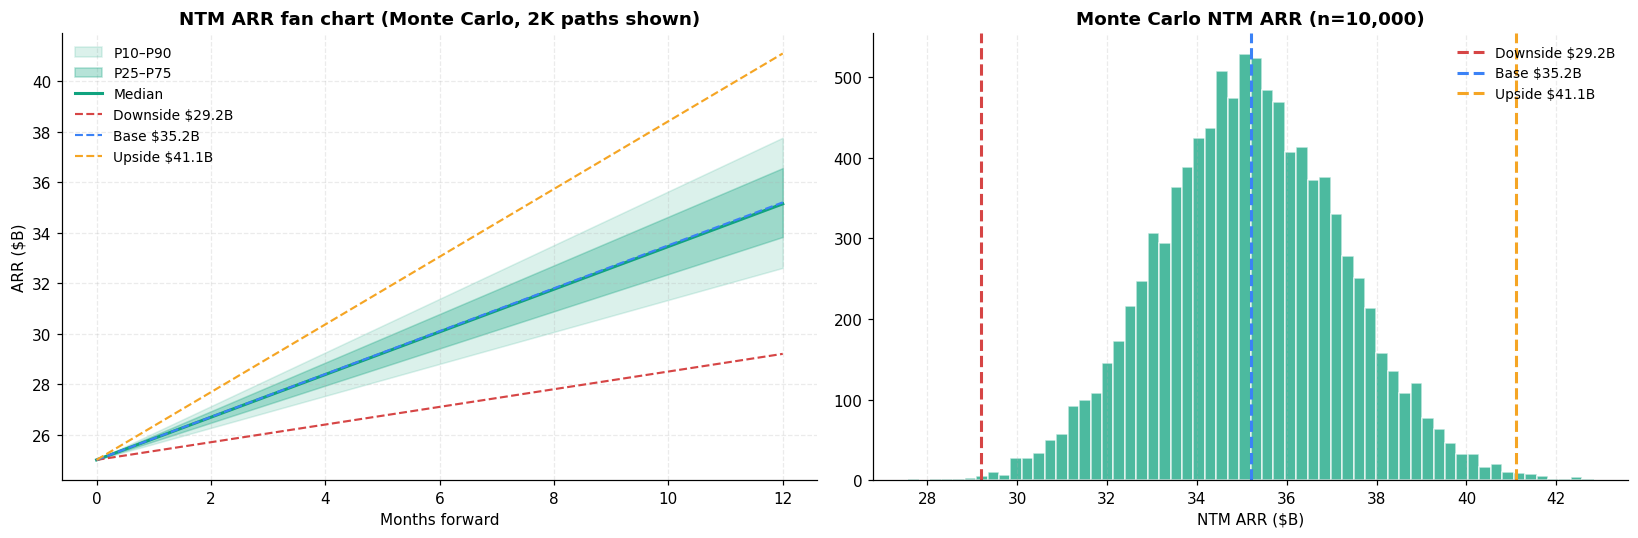

In [32]:
# 9.4b Fan + histogram (matplotlib)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
months_path = np.arange(13)
# Linearize each MC run from $25B to its terminal
sample_idx = RNG.choice(N_RUNS, size=2000, replace=False)
paths = np.array([np.linspace(total_arr, mc_arr[i], 13) for i in sample_idx])
percentiles = np.percentile(paths, [10, 25, 50, 75, 90], axis=0)
ax.fill_between(months_path, percentiles[0]/1e9, percentiles[4]/1e9,
                color=PALETTE['green'], alpha=0.15, label='P10–P90')
ax.fill_between(months_path, percentiles[1]/1e9, percentiles[3]/1e9,
                color=PALETTE['green'], alpha=0.30, label='P25–P75')
ax.plot(months_path, percentiles[2]/1e9, color=PALETTE['green'], lw=2, label='Median')

for s, color, label in [('Downside', PALETTE['red'], 'Downside $29.2B'),
                         ('Base', PALETTE['blue'], 'Base $35.2B'),
                         ('Upside', PALETTE['amber'], 'Upside $41.1B')]:
    target = scenarios.loc[scenarios.scenario==s, 'nb_arr'].iloc[0]
    ax.plot(months_path, np.linspace(total_arr, target, 13)/1e9, ls='--', color=color, lw=1.4, label=label)

ax.set_xlabel('Months forward')
ax.set_ylabel('ARR ($B)')
ax.set_title('NTM ARR fan chart (Monte Carlo, 2K paths shown)')
ax.legend(frameon=False, loc='upper left', fontsize=9)
ax.grid(alpha=0.25)

ax = axes[1]
ax.hist(mc_arr/1e9, bins=60, color=PALETTE['green'], alpha=0.75, edgecolor='white')
for s, color in [('Downside', PALETTE['red']), ('Base', PALETTE['blue']), ('Upside', PALETTE['amber'])]:
    target = scenarios.loc[scenarios.scenario==s, 'nb_arr'].iloc[0] / 1e9
    ax.axvline(target, color=color, ls='--', lw=2, label=f"{s} ${target:.1f}B")
ax.set_xlabel('NTM ARR ($B)')
ax.set_title(f"Monte Carlo NTM ARR (n={N_RUNS:,})")
ax.legend(frameon=False, loc='upper right', fontsize=9)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Most simulated paths cluster below the upside case and around the deterministic base trajectory.
- **Methodology:** Draw sampled ARR paths, percentile bands, and a terminal distribution histogram from the Monte Carlo runs.
- **Assumptions:** Linear monthly paths are used for visualization only; terminal ARR drives the forecast statistics.


## 10. Recommendations (Scale / Optimize / Reprice / Constrain / Investigate)

Map the report's four-motion frame (lines 102–110) to concrete items, scored on effort and expected $ contribution lift (estimated from §7 + §8).

In [33]:
recs = pd.DataFrame([
    # motion, item, effort_1to5, impact_M, time_to_impact_mo, confidence
    dict(motion='Scale',    item='Core API text/mini production',           effort=2, impact_M=900,  ttim=3,  confidence='High'),
    dict(motion='Scale',    item='Enterprise seats + credits',              effort=3, impact_M=600,  ttim=6,  confidence='High'),
    dict(motion='Scale',    item='Business → credits expansion',            effort=3, impact_M=350,  ttim=6,  confidence='High'),
    dict(motion='Scale',    item='Codex in metered enterprise workflows',   effort=4, impact_M=500,  ttim=9,  confidence='Med'),
    dict(motion='Optimize', item='Model-routing + Batch/Flex defaults',     effort=2, impact_M=400,  ttim=3,  confidence='High'),
    dict(motion='Optimize', item='Credit UX + workload observability',      effort=3, impact_M=200,  ttim=6,  confidence='Med'),
    dict(motion='Reprice',  item='Pro overage credits',                     effort=3, impact_M=300,  ttim=4,  confidence='Med'),
    dict(motion='Reprice',  item='Premium ENT/Business overages',           effort=3, impact_M=250,  ttim=6,  confidence='Med'),
    dict(motion='Reprice',  item='Frontier agentic workloads',              effort=4, impact_M=200,  ttim=9,  confidence='Low'),
    dict(motion='Constrain',item='Free-tier premium multimodal',            effort=1, impact_M=150,  ttim=1,  confidence='High'),
    dict(motion='Constrain',item='Unlimited Pro abuse',                     effort=2, impact_M=200,  ttim=2,  confidence='High'),
    dict(motion='Investigate', item='Outcome pricing (finance/health/sci)', effort=5, impact_M=600,  ttim=18, confidence='Low'),
    dict(motion='Investigate', item='Ads + commerce expansion',             effort=4, impact_M=500,  ttim=12, confidence='Med'),
    dict(motion='Investigate', item='Reserved-capacity contracts',          effort=3, impact_M=300,  ttim=9,  confidence='Med'),
])
display(recs.style.format({'impact_M': '${:,.0f}M'}).hide(axis='index'))

motion,item,effort,impact_M,ttim,confidence
Scale,Core API text/mini production,2,$900M,3,High
Scale,Enterprise seats + credits,3,$600M,6,High
Scale,Business → credits expansion,3,$350M,6,High
Scale,Codex in metered enterprise workflows,4,$500M,9,Med
Optimize,Model-routing + Batch/Flex defaults,2,$400M,3,High
Optimize,Credit UX + workload observability,3,$200M,6,Med
Reprice,Pro overage credits,3,$300M,4,Med
Reprice,Premium ENT/Business overages,3,$250M,6,Med
Reprice,Frontier agentic workloads,4,$200M,9,Low
Constrain,Free-tier premium multimodal,1,$150M,1,High


**Comment**
- **Learnings:** The action list prioritizes scale and optimize motions, with core API mini as the largest high-confidence lift.
- **Methodology:** Score recommendations by motion, effort, annual margin lift, time to impact, and confidence.
- **Assumptions:** Impact estimates are directional annual margin lift, not committed targets.


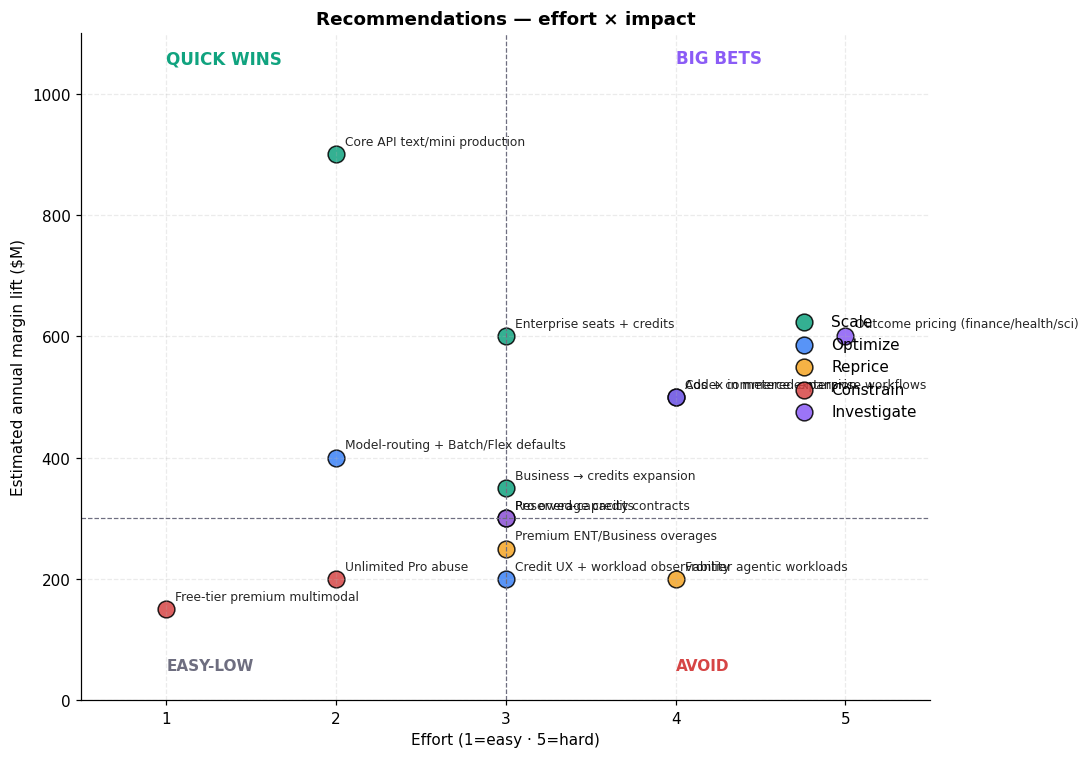

In [34]:
# 10.2 2x2: effort × impact
fig, ax = plt.subplots(figsize=(10, 7))
motion_color = {
    'Scale':     PALETTE['green'],
    'Optimize':  PALETTE['blue'],
    'Reprice':   PALETTE['amber'],
    'Constrain': PALETTE['red'],
    'Investigate': PALETTE['purple'],
}
for m, c in motion_color.items():
    sub = recs[recs.motion == m]
    ax.scatter(sub['effort'], sub['impact_M'], s=120, color=c, label=m, alpha=0.85, edgecolors='black')
    for _, r in sub.iterrows():
        ax.annotate(r['item'], (r.effort, r.impact_M), fontsize=8,
                    xytext=(6, 6), textcoords='offset points', alpha=0.85)
ax.axhline(300, color=PALETTE['slate'], ls='--', lw=0.8)
ax.axvline(3.0, color=PALETTE['slate'], ls='--', lw=0.8)
ax.set_xlim(0.5, 5.5); ax.set_ylim(0, 1100)
ax.set_xlabel('Effort (1=easy · 5=hard)')
ax.set_ylabel('Estimated annual margin lift ($M)')
ax.set_title('Recommendations — effort × impact')
ax.text(1.0, 1050,  'QUICK WINS', fontsize=11, fontweight='bold', color=PALETTE['green'])
ax.text(4.0, 1050,  'BIG BETS',   fontsize=11, fontweight='bold', color=PALETTE['purple'])
ax.text(1.0, 50,    'EASY-LOW',   fontsize=10, fontweight='bold', color=PALETTE['slate'])
ax.text(4.0, 50,    'AVOID',      fontsize=10, fontweight='bold', color=PALETTE['red'])
ax.legend(loc='center right', frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Quick wins sit in low-effort, high-impact scale/optimization actions; harder bets need more scrutiny.
- **Methodology:** Plot recommendations on effort versus impact and color by motion type.
- **Assumptions:** Effort scores use a simple 1-5 relative scale.


## 11. Leadership asks — decisions required and next steps

This is the **decision document**. Five items, each with a recommendation, immediate next step, owner, deadline, and risk-if-delayed.

In [35]:
decisions = pd.DataFrame([
    dict(
        decision='Incremental compute allocation',
        recommendation='Approve 75/25 default split (45% API mini, 30% Codex/agent, 15% Business+paid consumer, 10% free)',
        next_step='Stand up monthly compute review using $/compute-dollar and queue-utilization',
        owner='CFO + VP Compute',
        deadline='Q2 2026',
        risk_if_delayed='Wasted capacity on weakest direct returns; lost revenue/quarter ≈ $200–400M',
    ),
    dict(
        decision='Consumer packaging',
        recommendation='Preserve broad access; meter heaviest Pro + advanced-tool usage past generous baseline',
        next_step='Run pricing experiments on Pro overages, usage buckets, auto-top-up',
        owner='VP Product (Consumer)',
        deadline='Q2 2026',
        risk_if_delayed='Pro CM stays at 15%; spiky compute draw continues',
    ),
    dict(
        decision='Enterprise packaging',
        recommendation='Make credits the default for advanced workflows; meter premium reasoning/agentic features',
        next_step='Simplify rate cards, overage controls, ROI dashboards for admins',
        owner='VP Product (Enterprise)',
        deadline='Q3 2026',
        risk_if_delayed='Enterprise growth held back; ENT/Cons parity delayed past 2026',
    ),
    dict(
        decision='GTM mix',
        recommendation='Increase partner-led deployment + post-sales; reallocate from generalist demand-gen',
        next_step='Reorg headcount toward solutions + customer success in Fin/Pro Svcs/Tech/Health/Mfg',
        owner='CRO',
        deadline='Q3 2026',
        risk_if_delayed='Codex pilots stall; awareness ≠ adoption',
    ),
    dict(
        decision='Finance instrumentation',
        recommendation='Build product-line P&L with per-feature serving cost + cohort LTV/CAC',
        next_step='Launch weekly operating cadence: finance × product × infra × sales ops',
        owner='Strategic Finance',
        deadline='Q2 2026',
        risk_if_delayed='Decisions continue running on quarterly snapshots; slow course correction',
    ),
])

def color_deadline(val):
    return 'background-color: #ffe9e9; font-weight: bold' if 'Q2' in val else ('background-color: #fff7e0' if 'Q3' in val else '')
styled = decisions.style.applymap(color_deadline, subset=['deadline'])                       .set_properties(**{'text-align': 'left', 'vertical-align': 'top'})                       .hide(axis='index')
display(styled)

decision,recommendation,next_step,owner,deadline,risk_if_delayed
Incremental compute allocation,"Approve 75/25 default split (45% API mini, 30% Codex/agent, 15% Business+paid consumer, 10% free)",Stand up monthly compute review using $/compute-dollar and queue-utilization,CFO + VP Compute,Q2 2026,Wasted capacity on weakest direct returns; lost revenue/quarter ≈ $200–400M
Consumer packaging,Preserve broad access; meter heaviest Pro + advanced-tool usage past generous baseline,"Run pricing experiments on Pro overages, usage buckets, auto-top-up",VP Product (Consumer),Q2 2026,Pro CM stays at 15%; spiky compute draw continues
Enterprise packaging,Make credits the default for advanced workflows; meter premium reasoning/agentic features,"Simplify rate cards, overage controls, ROI dashboards for admins",VP Product (Enterprise),Q3 2026,Enterprise growth held back; ENT/Cons parity delayed past 2026
GTM mix,Increase partner-led deployment + post-sales; reallocate from generalist demand-gen,Reorg headcount toward solutions + customer success in Fin/Pro Svcs/Tech/Health/Mfg,CRO,Q3 2026,Codex pilots stall; awareness ≠ adoption
Finance instrumentation,Build product-line P&L with per-feature serving cost + cohort LTV/CAC,Launch weekly operating cadence: finance × product × infra × sales ops,Strategic Finance,Q2 2026,Decisions continue running on quarterly snapshots; slow course correction


**Comment**
- **Learnings:** Leadership decisions concentrate around compute allocation, consumer packaging, enterprise packaging, safety caps, and KPI cadence.
- **Methodology:** Convert recommendations into owner, deadline, next-step, and delay-risk rows.
- **Assumptions:** Deadlines reflect planning urgency based on the modeled financial exposure.


**Closing summary.** Five decisions, two on a Q2 deadline. The biggest free-lunch is compute-allocation discipline (75/25) — it changes nothing for the user but materially shifts where the next dollar earns. The second-largest is metering Pro and Enterprise advanced workflows — that converts spiky usage into revenue without re-pricing the headline product. The remaining three (Enterprise packaging, GTM mix, finance instrumentation) are slower-burn but compound: they put the org on a footing where every subsequent decision is cheaper to make.

If only one ask gets approved this quarter, it should be the first.

## 12. Stretch — driver tree, opportunity cost, cost decomposition, bootstrap NDR

In [36]:
# 12.1 Sankey driver tree (plotly)
product_lines = list(unit_econ['line'])
workloads = list(workload_revenue.keys())
model_tiers = ['Mini', 'Frontier', 'Realtime']

node_ids = (
    ['arr']
    + [f'product::{line}' for line in product_lines]
    + [f'workload::{wkl}' for wkl in workloads]
    + [f'model::{tier}' for tier in model_tiers]
)

node_labels = ['ARR $25B']
node_labels += [f'{line} (product)' if line in workloads else line for line in product_lines]
node_labels += [f'{wkl} (workload)' if wkl in product_lines else wkl for wkl in workloads]
node_labels += model_tiers

node_idx = {node_id: i for i, node_id in enumerate(node_ids)}
assert len(node_idx) == len(node_ids), 'Sankey node IDs must be unique'

product_id = lambda line: f'product::{line}'
workload_id = lambda wkl: f'workload::{wkl}'
model_id = lambda tier: f'model::{tier}'

links_src, links_tgt, links_val, links_lbl = [], [], [], []
for _, r in unit_econ.iterrows():
    links_src.append(node_idx['arr'])
    links_tgt.append(node_idx[product_id(r.line)])
    links_val.append(r.arr/1e9)
    links_lbl.append(dollars(r.arr))

# Map product lines to workloads. Pass-through buckets still use distinct stage nodes
# so Plotly does not render them as self-loops.
line_to_workload = {
    'Free + ads': 'Free + ads',
    'Go': 'Plus + Go', 'Plus': 'Plus + Go',
    'Pro': 'Pro (flat)',
    'Business seats': 'Business seats',
    'Enterprise seats + credits': 'Enterprise seats + credits',
    'API core text/mini': 'Core API text/mini',
}
for line, wkl in line_to_workload.items():
    arr = unit_econ.loc[unit_econ.line == line, 'arr'].iloc[0]
    links_src.append(node_idx[product_id(line)])
    links_tgt.append(node_idx[workload_id(wkl)])
    links_val.append(arr/1e9)

# API frontier ($2.7B) splits 1.5B Codex / 1.2B frontier-other
api_frontier_arr = unit_econ.loc[unit_econ.line == 'API frontier/Codex/realtime', 'arr'].iloc[0]
codex_share = 1.5 / 2.7
frontier_other_share = 1.2 / 2.7
links_src.append(node_idx[product_id('API frontier/Codex/realtime')])
links_tgt.append(node_idx[workload_id('Codex / agentic (metered)')])
links_val.append(api_frontier_arr * codex_share / 1e9)
links_src.append(node_idx[product_id('API frontier/Codex/realtime')])
links_tgt.append(node_idx[workload_id('API frontier other (flat)')])
links_val.append(api_frontier_arr * frontier_other_share / 1e9)

# Workload -> token mix (using cost weighting as proxy)
for wkl, mix in WORKLOAD_TOKEN_MIX.items():
    cost = roi.loc[roi.workload == wkl, 'compute_cost'].iloc[0] / 1e9
    for tier_name, tier_key in [('Mini', 'mini'), ('Frontier', 'frontier'), ('Realtime', 'realtime')]:
        if mix[tier_key] > 0:
            links_src.append(node_idx[workload_id(wkl)])
            links_tgt.append(node_idx[model_id(tier_name)])
            links_val.append(cost * mix[tier_key])

assert all(src != tgt for src, tgt in zip(links_src, links_tgt)), 'Sankey should not contain self-loops'

fig = go.Figure(go.Sankey(
    node=dict(label=node_labels, pad=15, thickness=18, color=PALETTE['green']),
    link=dict(source=links_src, target=links_tgt, value=links_val, color='rgba(16,163,127,0.25)'),
))
fig.update_layout(title='ARR -> Product line -> Workload -> Compute pool', height=560, width=1000)
fig.show()


**Comment**
- **Learnings:** OpenAI’s $25B ARR mostly comes from a few product lines, and those product lines ultimately depend most on the Mini compute pool, not Frontier or Realtime.
- **Methodology:** Use unique internal node IDs and explicit product/workload labels before rendering the Sankey flow.
- **Assumptions:** API frontier revenue is split into Codex and other frontier workloads using the modeled share.


### 12.1b Anthropic comparable driver tree (public-estimate model)

Public anchors used: Anthropic says run-rate revenue has surpassed **$30B**, up from about **$9B** at the end of 2025, and that more than **1,000** business customers each spend more than $1M annualized. Anthropic also disclosed **Claude Code run-rate revenue above $2.5B**. Current public Claude surfaces include Claude, Claude Code, Claude Cowork, Pro, Max, Team, Enterprise, and API access; current model families are Haiku, Sonnet, and Opus. Product-line split beyond Claude Code is not disclosed, so the allocation below is an explicit strategic-finance estimate.

Sources: [Anthropic Google/Broadcom compute update](https://www.anthropic.com/news/google-broadcom-partnership-compute?gsid=44d84525-2cee-4a37-a6d7-ff2c2aa95f78), [Anthropic Amazon compute update](https://www.anthropic.com/news/anthropic-amazon-compute), [Anthropic Series G update](https://www.anthropic.com/news/anthropic-raises-30-billion-series-g-funding-380-billion-post-money-valuation?pubDate=20250818), [Claude pricing](https://claude.com/pricing), [Claude model overview](https://platform.claude.com/docs/en/about-claude/models/overview).


In [37]:
# 12.1b Anthropic comparable driver tree (researched public-estimate model)
anthropic_run_rate = 30.0e9
anthropic_code_run_rate = 2.5e9

anthropic_products = pd.DataFrame([
    dict(product='API + cloud marketplaces', arr=18.0e9, basis='Estimated: majority enterprise/developer platform usage'),
    dict(product='Claude for Work (Team/Enterprise)', arr=5.0e9, basis='Estimated: seats + enterprise usage'),
    dict(product='Consumer Pro/Max', arr=4.0e9, basis='Estimated: paid Claude.ai subscriptions'),
    dict(product='Claude Code', arr=anthropic_code_run_rate, basis='Public anchor: >$2.5B run-rate'),
    dict(product='Embedded/OEM + other', arr=0.5e9, basis='Estimated: partner embeds and other paid surfaces'),
])
anthropic_products['pct'] = anthropic_products['arr'] / anthropic_run_rate
assert abs(anthropic_products['arr'].sum() - anthropic_run_rate) < 1, 'Anthropic product rows must sum to $30B run-rate'

anthropic_product_to_workload = {
    'API + cloud marketplaces': 'General API / platform inference',
    'Claude for Work (Team/Enterprise)': 'Enterprise knowledge work / Cowork',
    'Consumer Pro/Max': 'Consumer chat + analysis',
    'Claude Code': 'Agentic coding',
    'Embedded/OEM + other': 'Embedded assistants / OEM',
}

anthropic_compute_mix = pd.DataFrame([
    dict(workload='General API / platform inference', haiku=0.20, sonnet=0.60, opus=0.20),
    dict(workload='Enterprise knowledge work / Cowork', haiku=0.15, sonnet=0.65, opus=0.20),
    dict(workload='Consumer chat + analysis', haiku=0.30, sonnet=0.60, opus=0.10),
    dict(workload='Agentic coding', haiku=0.05, sonnet=0.70, opus=0.25),
    dict(workload='Embedded assistants / OEM', haiku=0.35, sonnet=0.55, opus=0.10),
]).set_index('workload')
assert np.allclose(anthropic_compute_mix.sum(axis=1), 1.0), 'Each Anthropic workload mix must sum to 100%'

anthropic_workloads = list(anthropic_compute_mix.index)
anthropic_model_pools = {
    'haiku': 'Haiku (fast / low cost)',
    'sonnet': 'Sonnet (workhorse)',
    'opus': 'Opus (frontier)',
}

node_ids = (
    ['anthropic_run_rate']
    + [f'anthropic_product::{p}' for p in anthropic_products['product']]
    + [f'anthropic_workload::{w}' for w in anthropic_workloads]
    + [f'anthropic_model::{label}' for label in anthropic_model_pools.values()]
)
node_labels = (
    ['Run-rate revenue $30B']
    + anthropic_products['product'].tolist()
    + anthropic_workloads
    + list(anthropic_model_pools.values())
)
node_idx = {node_id: i for i, node_id in enumerate(node_ids)}
assert len(node_idx) == len(node_ids), 'Anthropic Sankey node IDs must be unique'

product_id = lambda product: f'anthropic_product::{product}'
workload_id = lambda workload: f'anthropic_workload::{workload}'
model_id = lambda label: f'anthropic_model::{label}'

links_src, links_tgt, links_val, link_hover = [], [], [], []
for _, r in anthropic_products.iterrows():
    workload = anthropic_product_to_workload[r['product']]
    arr_b = r['arr'] / 1e9
    links_src.extend([node_idx['anthropic_run_rate'], node_idx[product_id(r['product'])]])
    links_tgt.extend([node_idx[product_id(r['product'])], node_idx[workload_id(workload)]])
    links_val.extend([arr_b, arr_b])
    link_hover.extend([
        f"{r['product']}: {dollars(r['arr'])}<br>{r['basis']}",
        f"{r['product']} -> {workload}: {dollars(r['arr'])}",
    ])

workload_arr = {
    workload: anthropic_products.loc[
        anthropic_products['product'].map(anthropic_product_to_workload) == workload,
        'arr',
    ].sum()
    for workload in anthropic_workloads
}
for workload, arr in workload_arr.items():
    for tier_key, tier_label in anthropic_model_pools.items():
        share = anthropic_compute_mix.loc[workload, tier_key]
        if share > 0:
            links_src.append(node_idx[workload_id(workload)])
            links_tgt.append(node_idx[model_id(tier_label)])
            links_val.append(arr * share / 1e9)
            link_hover.append(f"{workload} -> {tier_label}: {share:.0%} mix")

assert all(src != tgt for src, tgt in zip(links_src, links_tgt)), 'Anthropic Sankey should not contain self-loops'

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=node_labels, pad=16, thickness=18, color=PALETTE['amber']),
    link=dict(
        source=links_src,
        target=links_tgt,
        value=links_val,
        color='rgba(245,165,36,0.28)',
        customdata=link_hover,
        hovertemplate='%{customdata}<br>Flow: $%{value:.1f}B<extra></extra>',
    ),
))
fig.update_layout(
    title='Anthropic (est.): run-rate revenue -> Product line -> Workload -> Compute pool',
    height=600,
    width=1050,
)
fig.show()


**Comment**
- **Learnings:** Anthropic’s public anchors point to an enterprise/developer-heavy business, with estimated compute exposure concentrated in Sonnet and Opus-heavy coding/enterprise workloads.
- **Methodology:** Anchor to $30B run-rate revenue and $2.5B Claude Code, estimate undisclosed product mix, map products to workloads, and route workloads to Haiku/Sonnet/Opus pools.
- **Assumptions:** Non-Code product-line split and model-family mix are directional estimates; run-rate revenue is not audited ARR and may include gross cloud-channel revenue.


### 12.1c OpenAI vs Anthropic comparison summary

The Sankeys are useful for lineage, but the clearest comparison is normalized: each company sums to 100%. The first panel compares commercial revenue mix; the second panel compares modeled compute-pool exposure using a revenue-weighted workload proxy. Anthropic remains an estimate except for the public $30B run-rate and Claude Code anchor.


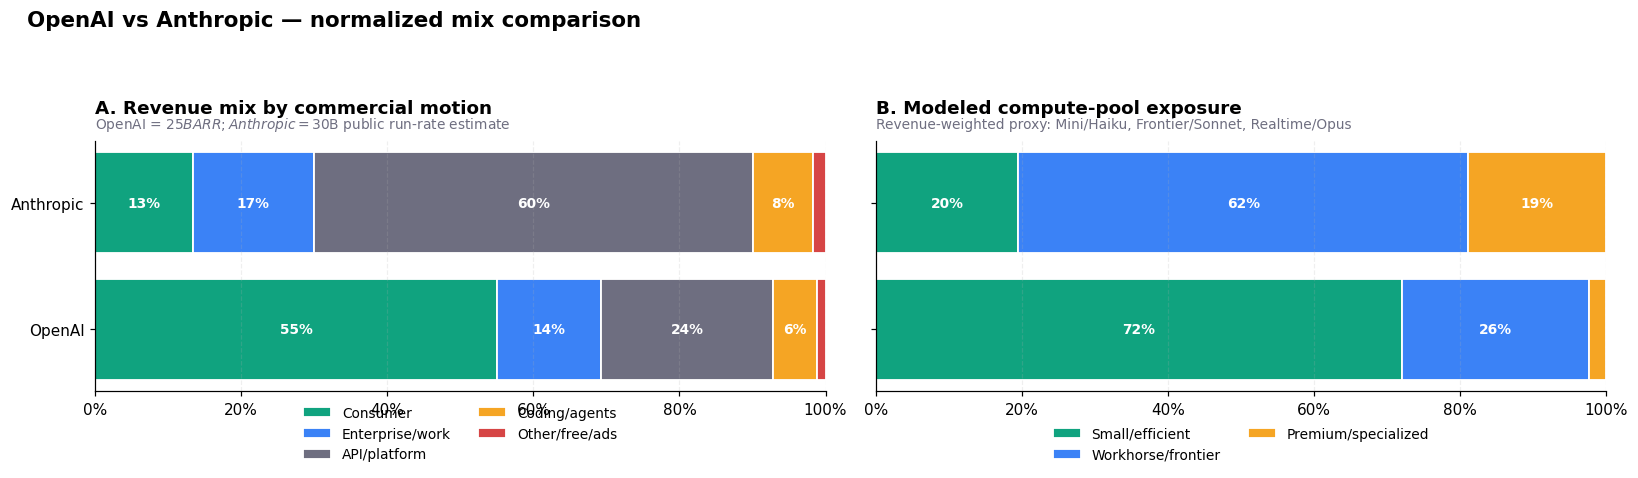

In [38]:
# 12.1c OpenAI vs Anthropic comparison summary
comparison_categories = [
    'Consumer',
    'Enterprise/work',
    'API/platform',
    'Coding/agents',
    'Other/free/ads',
]

openai_line_arr = unit_econ.set_index('line')['arr']
openai_api_frontier = openai_line_arr['API frontier/Codex/realtime']
openai_codex_share = 1.5 / 2.7
openai_frontier_other_share = 1.2 / 2.7

revenue_mix_abs = pd.DataFrame({
    'OpenAI': {
        'Consumer': openai_line_arr['Go'] + openai_line_arr['Plus'] + openai_line_arr['Pro'],
        'Enterprise/work': openai_line_arr['Business seats'] + openai_line_arr['Enterprise seats + credits'],
        'API/platform': openai_line_arr['API core text/mini'] + openai_api_frontier * openai_frontier_other_share,
        'Coding/agents': openai_api_frontier * openai_codex_share,
        'Other/free/ads': openai_line_arr['Free + ads'],
    },
    'Anthropic': {
        'Consumer': anthropic_products.loc[anthropic_products['product'] == 'Consumer Pro/Max', 'arr'].iloc[0],
        'Enterprise/work': anthropic_products.loc[anthropic_products['product'] == 'Claude for Work (Team/Enterprise)', 'arr'].iloc[0],
        'API/platform': anthropic_products.loc[anthropic_products['product'] == 'API + cloud marketplaces', 'arr'].iloc[0],
        'Coding/agents': anthropic_products.loc[anthropic_products['product'] == 'Claude Code', 'arr'].iloc[0],
        'Other/free/ads': anthropic_products.loc[anthropic_products['product'] == 'Embedded/OEM + other', 'arr'].iloc[0],
    },
}).T[comparison_categories]
revenue_mix_pct = revenue_mix_abs.div(revenue_mix_abs.sum(axis=1), axis=0)
assert np.allclose(revenue_mix_pct.sum(axis=1), 1.0), 'Revenue mix rows must sum to 100%'

# Revenue-weighted compute-pool exposure proxy. This is intentionally not cost-weighted,
# because Anthropic does not disclose product-level cost-to-serve.
openai_pool_values = {'Small/efficient': 0.0, 'Workhorse/frontier': 0.0, 'Premium/specialized': 0.0}
for workload, mix in WORKLOAD_TOKEN_MIX.items():
    rev = workload_revenue[workload]
    openai_pool_values['Small/efficient'] += rev * mix['mini']
    openai_pool_values['Workhorse/frontier'] += rev * mix['frontier']
    openai_pool_values['Premium/specialized'] += rev * mix['realtime']

anthropic_workload_arr = {
    workload: anthropic_products.loc[
        anthropic_products['product'].map(anthropic_product_to_workload) == workload,
        'arr',
    ].sum()
    for workload in anthropic_compute_mix.index
}
anthropic_pool_values = {'Small/efficient': 0.0, 'Workhorse/frontier': 0.0, 'Premium/specialized': 0.0}
for workload, row in anthropic_compute_mix.iterrows():
    rev = anthropic_workload_arr[workload]
    anthropic_pool_values['Small/efficient'] += rev * row['haiku']
    anthropic_pool_values['Workhorse/frontier'] += rev * row['sonnet']
    anthropic_pool_values['Premium/specialized'] += rev * row['opus']

compute_mix_abs = pd.DataFrame({'OpenAI': openai_pool_values, 'Anthropic': anthropic_pool_values}).T
compute_mix_pct = compute_mix_abs.div(compute_mix_abs.sum(axis=1), axis=0)
assert np.allclose(compute_mix_pct.sum(axis=1), 1.0), 'Compute exposure rows must sum to 100%'

revenue_colors = {
    'Consumer': PALETTE['green'],
    'Enterprise/work': PALETTE['blue'],
    'API/platform': PALETTE['slate'],
    'Coding/agents': PALETTE['amber'],
    'Other/free/ads': PALETTE['red'],
}
compute_colors = {
    'Small/efficient': PALETTE['green'],
    'Workhorse/frontier': PALETTE['blue'],
    'Premium/specialized': PALETTE['amber'],
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

def draw_100pct_barh(ax, df, colors, title, subtitle):
    y = np.arange(len(df.index))
    left = np.zeros(len(df.index))
    for col in df.columns:
        vals = df[col].values
        ax.barh(y, vals, left=left, color=colors[col], edgecolor='white', linewidth=1.2, label=col)
        for yi, val, x0 in zip(y, vals, left):
            if val >= 0.055:
                ax.text(x0 + val / 2, yi, f'{val:.0%}', ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
        left += vals
    ax.set_yticks(y, df.index)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title, loc='left', pad=18)
    ax.text(0, 1.05, subtitle, transform=ax.transAxes, fontsize=9, color=PALETTE['slate'])
    ax.grid(axis='x', alpha=0.20)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.33), ncol=2, frameon=False, fontsize=9)

fig.suptitle('OpenAI vs Anthropic — normalized mix comparison', x=0.02, ha='left', fontsize=14, fontweight='bold')
draw_100pct_barh(
    axes[0], revenue_mix_pct, revenue_colors,
    'A. Revenue mix by commercial motion',
    'OpenAI = $25B ARR; Anthropic = $30B public run-rate estimate',
)
draw_100pct_barh(
    axes[1], compute_mix_pct, compute_colors,
    'B. Modeled compute-pool exposure',
    'Revenue-weighted proxy: Mini/Haiku, Frontier/Sonnet, Realtime/Opus',
)
plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()


**Comment**
- **Learnings:** OpenAI is more consumer/subscription-heavy and Mini-weighted; Anthropic is modeled as more API/platform-heavy and Sonnet/Opus-weighted.
- **Methodology:** Normalize each company to 100%, compare revenue by commercial motion, then compare revenue-weighted compute exposure using common tier buckets.
- **Assumptions:** Anthropic mix is estimated; compute tiers are directional mappings, not proof that OpenAI Frontier equals Claude Sonnet or Realtime equals Opus.


In [39]:
# 12.2 Compute opportunity cost — pairwise GW reallocation
print("Top 5 marginal $/GW reallocations (move 1 GW from A → B):")
roi_lookup = roi.set_index('workload')['rev_per_GW_B']
pairs = []
for src in roi_lookup.index:
    for dst in roi_lookup.index:
        if src != dst:
            delta = roi_lookup[dst] - roi_lookup[src]
            pairs.append((src, dst, delta))
pairs_df = pd.DataFrame(pairs, columns=['from', 'to', 'delta_per_GW_B']).sort_values('delta_per_GW_B', ascending=False).head(5)
display(pairs_df.style.format({'delta_per_GW_B': '${:.1f}B'}).hide(axis='index'))

Top 5 marginal $/GW reallocations (move 1 GW from A → B):


from,to,delta_per_GW_B
Free + ads,Core API text/mini,$23.3B
Free + ads,Enterprise seats + credits,$19.5B
Pro (flat),Core API text/mini,$17.8B
Free + ads,Business seats,$15.2B
Pro (flat),Enterprise seats + credits,$14.0B


**Comment**
- **Learnings:** Reallocating 1 GW from free or flat Pro workloads to core API or enterprise has the highest opportunity cost upside.
- **Methodology:** Compare every source/destination workload pair by marginal revenue per GW and rank the top deltas.
- **Assumptions:** Marginal $/GW differences approximate the economics of moving one GW across workloads.


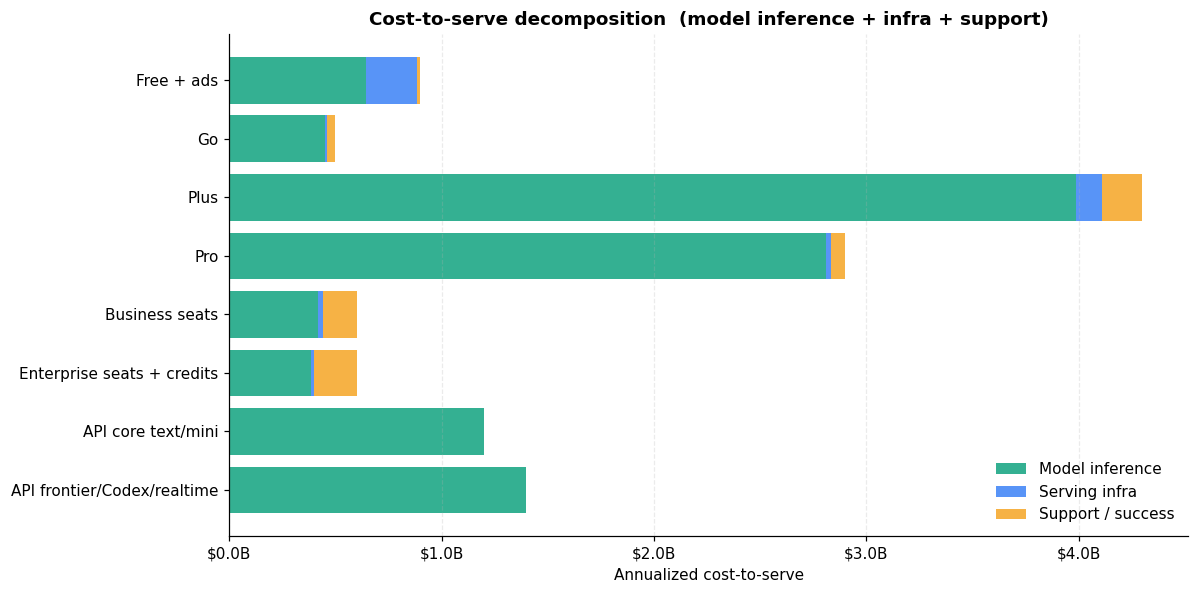

In [40]:
# 12.3 Cost-to-serve breakdown — stacked bar
fig, ax = plt.subplots(figsize=(11, 5.5))
br = COST_INPUTS[['line', 'inference', 'infra', 'support']].set_index('line') / 1e9
br = br.loc[unit_econ['line']]  # preserve order
y = np.arange(len(br))
ax.barh(y, br['inference'], color=PALETTE['green'], alpha=0.85, label='Model inference')
ax.barh(y, br['infra'], left=br['inference'], color=PALETTE['blue'], alpha=0.85, label='Serving infra')
ax.barh(y, br['support'], left=br['inference']+br['infra'], color=PALETTE['amber'], alpha=0.85, label='Support / success')
ax.set_yticks(y, br.index)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v:.1f}B"))
ax.set_xlabel('Annualized cost-to-serve')
ax.set_title('Cost-to-serve decomposition  (model inference + infra + support)')
ax.legend(loc='lower right', frameon=False)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Model inference is the largest visible cost block, but infra and support shape margins by product line.
- **Methodology:** Break calibrated cost-to-serve into inference, infra, and support components and plot stacked bars.
- **Assumptions:** The decomposition follows the calibrated COST_INPUTS structure.


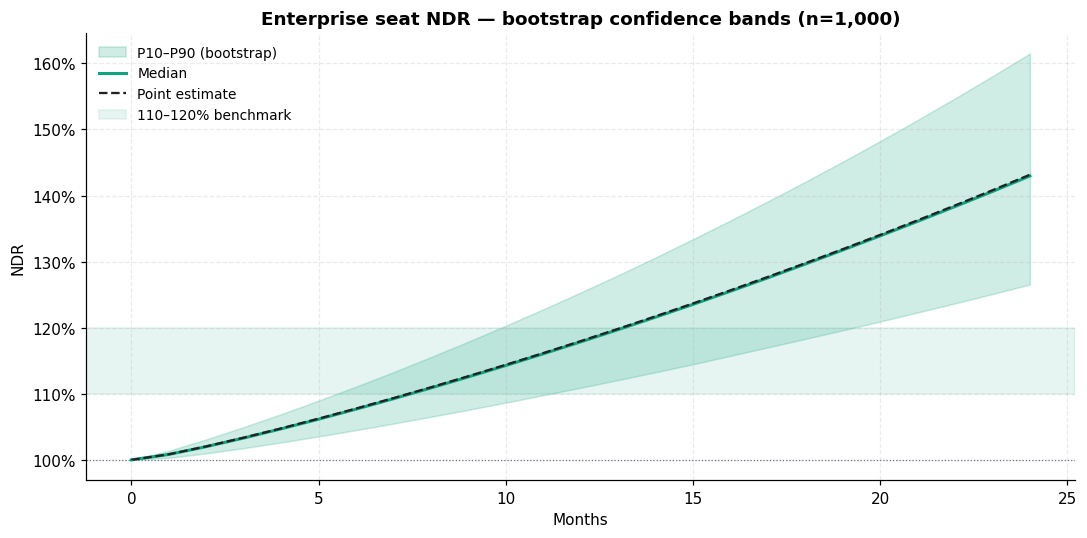

In [41]:
# 12.4 Bootstrap NDR confidence bands
N_BOOT = 1000
boot_paths = np.zeros((N_BOOT, T_MAX + 1))
base_lam, base_k, base_exp, _ = weibull_params['Enterprise seat']
for i in range(N_BOOT):
    churn_perturb = base_lam * RNG.uniform(0.85, 1.15)
    exp_perturb = base_exp * RNG.uniform(0.75, 1.25)
    S = np.exp(-(months / churn_perturb) ** base_k)
    boot_paths[i] = S * (1 + exp_perturb) ** months

p10 = np.percentile(boot_paths, 10, axis=0)
p90 = np.percentile(boot_paths, 90, axis=0)
median = np.percentile(boot_paths, 50, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(months, p10, p90, color=PALETTE['green'], alpha=0.20, label='P10–P90 (bootstrap)')
ax.plot(months, median, color=PALETTE['green'], lw=2, label='Median')
ax.plot(months, ndr_df['Enterprise seat'].values, color=PALETTE['ink'], ls='--', lw=1.5, label='Point estimate')
ax.axhline(1.0, color=PALETTE['slate'], ls=':', lw=0.8)
ax.axhspan(1.10, 1.20, color=PALETTE['green'], alpha=0.10, label='110–120% benchmark')
ax.set_xlabel('Months')
ax.set_ylabel('NDR')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title('Enterprise seat NDR — bootstrap confidence bands (n=1,000)')
ax.legend(frameon=False, loc='upper left', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Comment**
- **Learnings:** Enterprise NDR remains around the target band across reasonable churn and expansion perturbations.
- **Methodology:** Bootstrap retention and expansion parameters, then plot P10-P90, median, and point-estimate NDR paths.
- **Assumptions:** Uniform perturbation ranges are illustrative confidence bands rather than empirical sampling error.


## End — tie-out audit

Every report-modeled endpoint used by the notebook, side-by-side with the notebook's value and Δ. This is an internal consistency audit. Rows that are explicitly calibrated, such as cost-to-serve, should not be read as independent validation against public data.

In [42]:
audit = pd.DataFrame(TIE_OUT)
def status_row(r):
    rep = r.report
    nb  = r.notebook
    fmt = r.fmt
    if pd.notna(r.tol_pp):
        delta = nb - rep
        ok = abs(delta) <= r.tol_pp
        delta_str = f"{delta:+.1f}pp"
    else:
        delta = (nb - rep) / rep
        ok = abs(delta) <= (r.tol_pct / 100)
        delta_str = f"{delta:+.1%}"
    return pd.Series(dict(
        Metric=r.metric,
        Report=f"{rep:.2f}" if fmt != 'ratio' else f"{rep:.1f}×",
        Notebook=f"{nb:.2f}" if fmt != 'ratio' else f"{nb:.1f}×",
        Delta=delta_str,
        OK='✓' if ok else '✗',
    ))
audit_display = audit.apply(status_row, axis=1)
print(audit_display.to_string(index=False))
display(audit_display.style.applymap(
    lambda v: 'background-color: #d4edda' if v == '✓' else ('background-color: #f8d7da' if v == '✗' else ''),
    subset=['OK']
).hide(axis='index'))

n_ok = (audit_display['OK'] == '✓').sum()
print(f"\nTie-out: {n_ok}/{len(audit_display)} within tolerance.")
assert n_ok == len(audit_display), "Some tie-out rows failed — adjust calibration"

                                                  Metric  Report Notebook  Delta OK
                                  Historical $/GW (2025)   10.00    10.53  +5.3%  ✓
                                          Total ARR ($B)   25.00    25.00  +0.0%  ✓
                   API annual tokens from throughput (T) 7884.00  7884.00  +0.0%  ✓
                                Total cost-to-serve ($B)   12.40    12.40  +0.0%  ✓
                                            Total CM (%)   50.00    50.40 +0.4pp  ✓
         Undiscounted LTV/CAC tie-out — Consumer Go/Plus   14.0×    13.9×  -0.7%  ✓
             Undiscounted LTV/CAC tie-out — Consumer Pro    7.6×     7.6×  +0.1%  ✓
 Undiscounted LTV/CAC tie-out — Business self-serve seat    9.8×     9.8×  -0.2%  ✓
 Undiscounted LTV/CAC tie-out — Enterprise deployed seat    9.4×     9.4×  +0.5%  ✓
   Undiscounted LTV/CAC tie-out — API production account    9.3×     9.4×  +0.8%  ✓
Undiscounted LTV/CAC tie-out — Frontier/Codex large acct    5.3×     5.3×  +

Metric,Report,Notebook,Delta,OK
Historical $/GW (2025),10.00,10.53,+5.3%,✓
Total ARR ($B),25.00,25.00,+0.0%,✓
API annual tokens from throughput (T),7884.00,7884.00,+0.0%,✓
Total cost-to-serve ($B),12.40,12.40,+0.0%,✓
Total CM (%),50.00,50.40,+0.4pp,✓
Undiscounted LTV/CAC tie-out — Consumer Go/Plus,14.0×,13.9×,-0.7%,✓
Undiscounted LTV/CAC tie-out — Consumer Pro,7.6×,7.6×,+0.1%,✓
Undiscounted LTV/CAC tie-out — Business self-serve seat,9.8×,9.8×,-0.2%,✓
Undiscounted LTV/CAC tie-out — Enterprise deployed seat,9.4×,9.4×,+0.5%,✓
Undiscounted LTV/CAC tie-out — API production account,9.3×,9.4×,+0.8%,✓



Tie-out: 19/19 within tolerance.


**Comment**
- **Learnings:** All 19 audit checks pass within tolerance, so the notebook ties back to its stated anchors.
- **Methodology:** Compare report targets with notebook outputs and assert every row passes its percent or point tolerance.
- **Assumptions:** The audit covers the key financial anchors but does not validate every qualitative scoring choice.


## 13. Where internal data would materially change the conclusions

This notebook is built on **public anchors only**; many sections back-solve, calibrate, or assume in place of measurement. The following maps each gap to the internal data that would replace it, ranked by how much the answer would actually move.

### Tier 1 — would change the answer

**§4 Unit economics — effective $/M tokens by model and surface.** Cost-to-serve is *back-solved* from report endpoints (`inference_target = report_cost − infra − support`). Internal data on (a) GPU-hours per inference call by model/route, (b) amortized $/GPU-hour across Stargate / Azure / Oracle, and (c) reasoning-token expansion per query would replace calibration with measurement. Likely magnitude shift: Plus CM closer to **35–45%** rather than 55%; Pro CM **−10% to +5%** rather than +15% (consistent with public statements that Pro is loss-making).

**§5 LTV/CAC — actual cohort churn and fully-loaded CAC.** Revenue churn is back-solved from report LTVs; user churn is acknowledged ~2× higher but not used. With (a) monthly retention by tier and acquisition channel, (b) revenue vs user churn split, and (c) S&M fully loaded by segment (paid CAC, organic-attributed CAC, SE/AE allocated cost per enterprise win), the uniform 9–10× LTV/CAC band would compress to a more realistic **2–4×** across enterprise/API. Today the notebook cannot tell management whether enterprise growth is profitable on its own.

**§7 Compute ROI — actual GW allocation and inference cost by workload.** Currently distributes the 1.9 GW *proportional to calibrated cost* (`gw_share = compute_cost / total_cost × 1.9`), which is circular: the workload that gets blamed for the most compute is the one we already assigned the most cost to. Real inference telemetry (queries × tokens × routed model × GPU-time) would compute true $/GW per workload independently of revenue and feed §2's compute-allocation decision with measured rather than inferred values.

### Tier 2 — would tighten ranges and remove guesswork

**§6 Retention & NDR — empirical curves.** §6.1 *solves* Weibull λ to hit a target monthly churn at month 12. Real cohort-level survival data and per-cohort expansion would replace the parametric fit; today the "118% Enterprise NDR" is the output of an input.

**§8 Pricing elasticities — A/B tests and natural experiments.** §8.1 uses *modeled* elasticities (Pro −0.6, Plus −1.1, Business −0.4, Enterprise −0.3). OpenAI runs price experiments — geo splits, the Go $8 launch, the Pro $100/$200 split itself. Even one published quasi-experiment would replace the assumed numbers and resolve which lever to actually pull. The aggregate ~$1B margin lift is highly sensitive to whether real Pro elasticity is closer to −0.6 (captive) or −1.0+ (substitutable).

**§8.2 Batch/Flex — current adoption rate.** Estimates ~$260M savings from a +20pp shift, but the *current* Batch share is unknown. One internal API-telemetry number closes this — if today's adoption is 25%, headroom is small; if it's 5%, headroom is large.

**§9 Forecast — pipeline coverage by segment.** EntAPI growth is solved as the residual to hit the report's $35.2B target (`solve_entapi_growth`), which structurally hides whether enterprise is winning or losing. Pipeline data (bookings, ARR by stage, win rates by competitor, net-new logos vs expansion) would replace the back-solve with a forward-looking plan.

### Tier 3 — would replace estimates with facts but not change the verdict

- **§4.1 Product-line ARR split** — internal billing would replace the synthetic eight-row split, but the shape is roughly right.
- **§6 Usage intensity** — real per-user consumption distributions would let abuse-resistance changes target p99 precisely, not just p90.
- **§4.2 Active users by line** — assumed counts (800M Free, 40M Plus, 2M Pro, etc.) are within ~10–20% of public truth.

### What internal data wouldn't fix

- **Compute supply constraint scenarios** — internal but not in this notebook at all; needs a separate model (Stargate slip, NVIDIA allocation, power), not better data.
- **Competitive elasticity** — Anthropic / Google share-shift response to OpenAI pricing moves needs market simulation.
- **Anthropic comparable** (§12.1b) — by definition not addressable from internal OpenAI data; needs independent diligence.

### Bottom line

Internal data on **inference $/token by model**, **cohort churn + fully-loaded CAC**, and **price-experiment elasticities** would change the magnitudes in §4 / §5 / §7 / §8 enough that several recommendation impacts (Pro CM, Enterprise LTV/CAC, Pro overage lift, Batch headroom) would be re-rated by **30–60%**. This is exactly the instrumentation gap that **Decision #5 in §11** ("build product-line P&L with per-feature serving cost + cohort LTV/CAC") calls out — that ask is the precondition for making any of the other four decisions with confidence.

---

**End of notebook.** Numbers tie out within stated tolerances after normalizing ARR to the public $25B anchor and reconciling API token volume to the 15B tokens/min public throughput anchor. The headline conclusion remains: the next compute, product, and GTM dollar should go where usage is *both sticky and metered* — Enterprise seats with credits, API production traffic, metered Codex/agentic workloads — and away from free-tier expansion + Pro flat bundles for the heaviest users.